In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import math

In [33]:
raw_data = pd.read_pickle('/Users/matiasochoa/Proyectos_Python/attrition_dataset.pkl')

#### EDA

In [34]:
df = raw_data.copy()
df.shape

(1426, 31)

In [35]:
cols_constant = [
    col for col in df.columns
    if df[col].nunique(dropna=False) == 1
]
print("Columnas eliminadas:\n")
for col in cols_constant:
    print(f'{col} : {df[col].unique()}')
df = df.drop(columns=cols_constant)


Columnas eliminadas:

EmployeeCount : [1]
Over18 : ['Y']
StandardHours : [8]


In [36]:
df.dtypes

hrs                        float64
absences                     int64
JobInvolvement             float64
PerformanceRating            int64
EnvironmentSatisfaction    float64
JobSatisfaction            float64
WorkLifeBalance            float64
Age                        float64
Attrition                   object
BusinessTravel              object
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeID                   int64
Gender                      object
JobLevel                     int64
JobRole                     object
MaritalStatus               object
MonthlyIncome              float64
NumCompaniesWorked         float64
PercentSalaryHike            int64
StockOptionLevel             int64
TotalWorkingYears          float64
TrainingTimesLastYear        int64
YearsAtCompany               int64
YearsSinceLastPromotion      int64
YearsWithCurrManager         int64
dtype: object

Chequear si no hay info de manera aleatoria o si en algunos de estos campos tiene sentido que sean nulos. 

Hipotesis Inicial:
- Los que no han reportado su **JobSatisfaction** ni su **EnviromentSatisfaction** esten bastante correlacionados con el attrition.

- **JobInvolvement** en caso de que sea una especie de calificacion dada por el jefe es probable que estos NAs lleven poco tiempo trabajando.

- **Age** faltando probablemente de manera aleatoria



In [37]:
(df.isnull().sum() / len(df) * 100)\
    .loc[lambda x: x > 0]\
    .sort_values(ascending=False)

JobSatisfaction            11.150070
JobInvolvement             10.308555
Age                         9.396914
MonthlyIncome               9.326788
EnvironmentSatisfaction     0.561010
WorkLifeBalance             0.490884
NumCompaniesWorked          0.420757
TotalWorkingYears           0.140252
dtype: float64

In [38]:
df[df['JobInvolvement'].isnull()]['YearsAtCompany'].value_counts().sort_index()

YearsAtCompany
0      6
1     31
2     14
3     17
4     14
5     10
6      5
7      4
8     12
9      6
10    13
11     1
13     2
16     1
19     2
20     1
21     1
23     1
31     1
32     1
33     1
37     1
40     2
Name: count, dtype: int64

In [39]:
df[df['JobSatisfaction'].isnull()]['YearsAtCompany'].value_counts().sort_index()

YearsAtCompany
0      5
1     27
2     14
3     12
4     16
5     20
6      7
7      6
8      6
9      9
10    11
11     4
13     3
14     2
15     1
18     2
19     1
20     2
21     2
22     4
32     1
33     1
34     1
40     2
Name: count, dtype: int64

Hay menos Attrition en los NA incluso asi que inputamos y no los tratamos diferente

In [40]:
pd.crosstab(df["JobSatisfaction"].isna(),
            df["Attrition"],
            normalize="index")

Attrition,No,Yes
JobSatisfaction,,
False,0.503552,0.496448
True,0.484277,0.515723


In [41]:
pd.crosstab(df["JobInvolvement"].isna(),
            df["Attrition"],
            normalize="index")

Attrition,No,Yes
JobInvolvement,,
False,0.500391,0.499609
True,0.510204,0.489796


In [42]:
print(df.duplicated().sum())

df = df.drop_duplicates()


76


- DistanceFromHome parece ser en kilometros

- JobLevel y Education son las unicas que llegan a 5

- PercentSalaryHike probablemente sea desde el ingreso dentro de la performance window


In [43]:
df.select_dtypes(include='number').describe().T

,count,mean,std,min,25%,50%,75%,max
hrs,1350.0,7.622180,1.429139,5.465741,6.442701,7.327445,8.663179,10.937261
absences,1350.0,12.585185,5.475310,1.000000,8.000000,13.000000,17.000000,23.000000
JobInvolvement,1208.0,2.709437,0.748936,1.000000,2.000000,3.000000,3.000000,4.000000
PerformanceRating,1350.0,3.157037,0.363971,3.000000,3.000000,3.000000,3.000000,4.000000
EnvironmentSatisfaction,1342.0,2.650522,1.130914,1.000000,2.000000,3.000000,4.000000,4.000000
JobSatisfaction,1196.0,2.645485,1.101420,1.000000,2.000000,3.000000,4.000000,4.000000
WorkLifeBalance,1343.0,2.702159,0.763777,1.000000,2.000000,3.000000,3.000000,4.000000
Age,1221.0,35.222768,9.341052,18.000000,29.000000,34.000000,41.000000,60.000000
DistanceFromHome,1350.0,9.285185,7.986794,1.000000,2.000000,7.000000,15.000000,29.000000
Education,1350.0,2.906667,1.015170,1.000000,2.000000,3.000000,4.000000,5.000000


In [44]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    print(f"\nColumna: {col}")
    print(df[col].unique())



Columna: Attrition
['Yes' 'No']

Columna: BusinessTravel
['Travel_Frequently' 'Travel_Rarely' 'Non-Travel']

Columna: Department
['Research & Development' 'Human Resources' 'Sales']

Columna: EducationField
['Life Sciences' 'Medical' 'Human Resources' 'Marketing'
 'Technical Degree' 'Other']

Columna: Gender
['Female' 'Male']

Columna: JobRole
['Research Scientist' 'Sales Executive' 'Manager' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative'
 'Sales Representative' 'Research Director' 'Human Resources']

Columna: MaritalStatus
['Single' 'Married' 'Divorced']


In [45]:
df['Attrition'] = df['Attrition'].apply(lambda x: 1 if x=='Yes' else 0)

df['Attrition'].mean()


np.float64(0.5266666666666666)

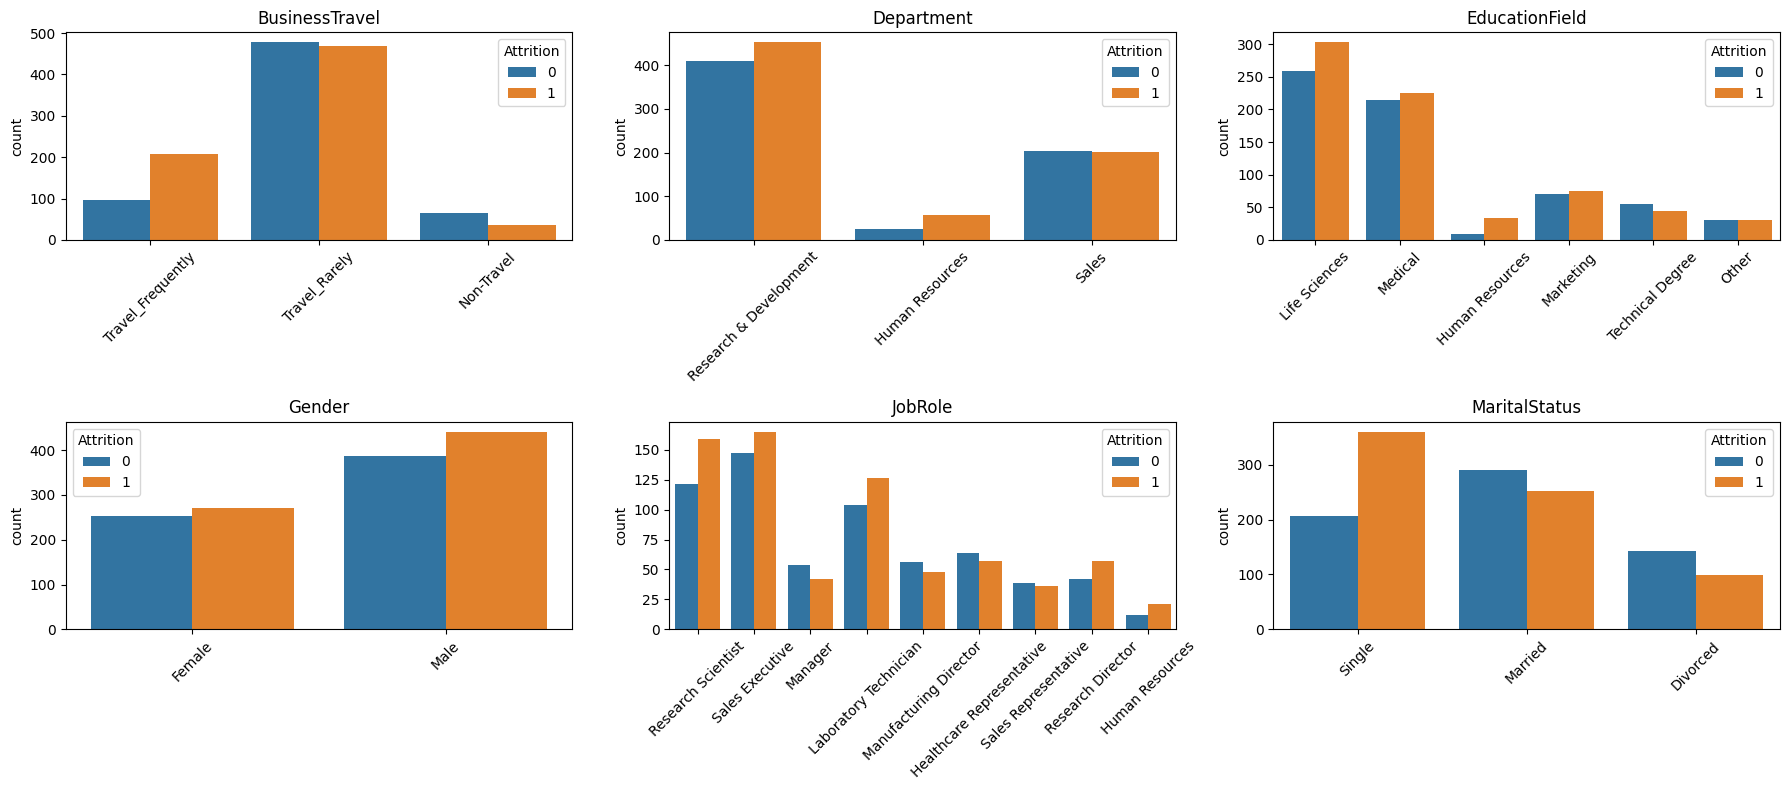

In [46]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

n_cols = 3
n_plots = len(cat_cols)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df,
        x=col,
        hue="Attrition",
        ax=axes[i]
    )
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [48]:
dfcat = df.copy()

cat_cols = df.select_dtypes(exclude='number').columns.tolist()

cols = cat_cols + ['Attrition']

dfcat = dfcat[cols]

dfcat = pd.get_dummies(dfcat, drop_first=False)

corre = dfcat.corr()

corre['Attrition'].sort_values(ascending=False)

Attrition                            1.000000
MaritalStatus_Single                 0.184503
BusinessTravel_Travel_Frequently     0.168622
EducationField_Human Resources       0.092971
Department_Human Resources           0.085799
JobRole_Research Scientist           0.042202
JobRole_Human Resources              0.034778
JobRole_Research Director            0.027659
EducationField_Life Sciences         0.021108
JobRole_Laboratory Technician        0.019205
Gender_Male                          0.014989
JobRole_Sales Executive              0.002393
Department_Research & Development   -0.004675
EducationField_Marketing            -0.009045
EducationField_Other                -0.011519
Gender_Female                       -0.014989
EducationField_Medical              -0.021312
JobRole_Sales Representative        -0.022669
JobRole_Healthcare Representative   -0.034937
JobRole_Manufacturing Director      -0.037686
Department_Sales                    -0.039821
EducationField_Technical Degree   

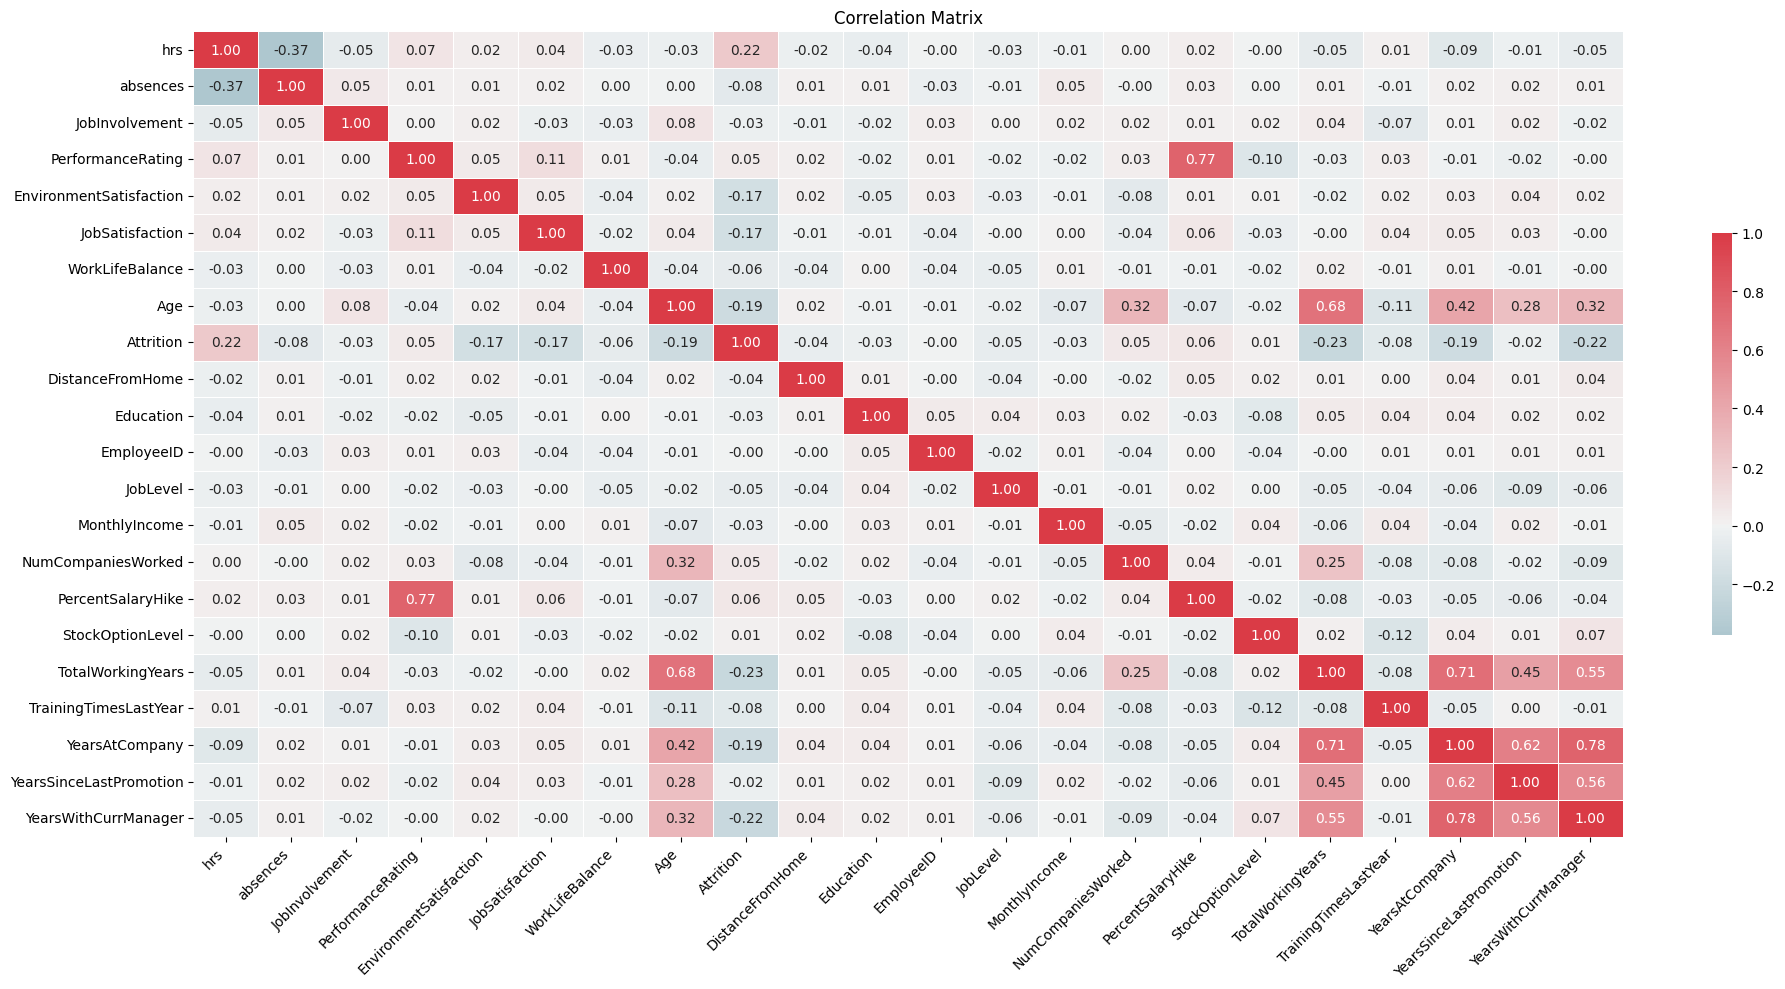

In [49]:
corre = df.select_dtypes(include='number').corr()

mask = np.triu(np.ones_like(corre, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

plt.figure(figsize=(20, 10))
sns.heatmap(corre, cmap=cmap, vmax=1., center=0,
square=False, linewidths=.5, cbar_kws={"shrink": .5}, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.xticks(rotation=45, ha="right") 
plt.tight_layout()
plt.show()

In [50]:
high_corr = corre.abs() > 0.75
print(corre[high_corr].stack().drop_duplicates())

hrs                hrs                     1.000000
PerformanceRating  PercentSalaryHike       0.774076
YearsAtCompany     YearsWithCurrManager    0.778874
dtype: float64


#### Tratamiento de NAs

No se identificaria ningun riesgo con inputar los missing ya que no estarian correlacionados fuertemente con la variable target, podemos probar un modelo con el input y otro dropeandolas. No hay filas que tengan mas de 2 NA practicamente

In [51]:
df.isna().sum(axis=1).value_counts().sort_index()

0    863
1    410
2     70
3      6
4      1
Name: count, dtype: int64

In [52]:
na_cols = df.columns[df.isna().any()]

results = []

for col in na_cols:
    na_indicator = df[col].isna().astype(int)
    corr = na_indicator.corr(df["Attrition"])
    results.append((col, corr))

na_corr_df = pd.DataFrame(results, columns=["Column", "NA_Attrition_Corr"])
na_corr_df = na_corr_df.sort_values(by="NA_Attrition_Corr", key=abs, ascending=False)


na_corr_df

,Column,NA_Attrition_Corr
7,TotalWorkingYears,0.036516
5,MonthlyIncome,-0.032396
4,Age,0.030582
6,NumCompaniesWorked,0.018735
1,EnvironmentSatisfaction,0.015206
0,JobInvolvement,-0.013476
3,WorkLifeBalance,0.006472
2,JobSatisfaction,0.004169


En lineas generales, aquellos empleados que trabajan más horas están sujetos a tener una mayor attrition, lo mismo ocurre con las inasistencias salvo cuando son muy elevadas lo que implicaria una especie de beneficio por antiguedad con lo cual tienen más licencia. Se concentran en aquellos que tienen un JobInvolvement de 1 y es más claro detectarlos mediante Satisfaction tanto de Enviroment como de Job como tambien la WorkLifeBlance, donde la diferencia se refleja aún mayor. La distancia no parecería incidir tanto.

Los empleados jovenes son más proclives a irse, tambien sucede con aquellos roles que son más bajos, ergo, también sucede con MonthlyIncome.

Si se observa lo que sucede con el historial laboral de la persona, aquellos que estan en una primera experiencia o tienden a moverse mucho son más proclives a irse, a diferencia de aquellos que tuvieron entre 2-4 trabajos.

Participaron en media en menos capacitaciones

Un hallazgo interesante es el comportamiento de Performance Rating donde el Attrition es mayor tanto para el valor más bajo como para el más alto, se podria hacer un test de hipotesis para verificar que los mejores empleados tienen mas probabilidad de irse

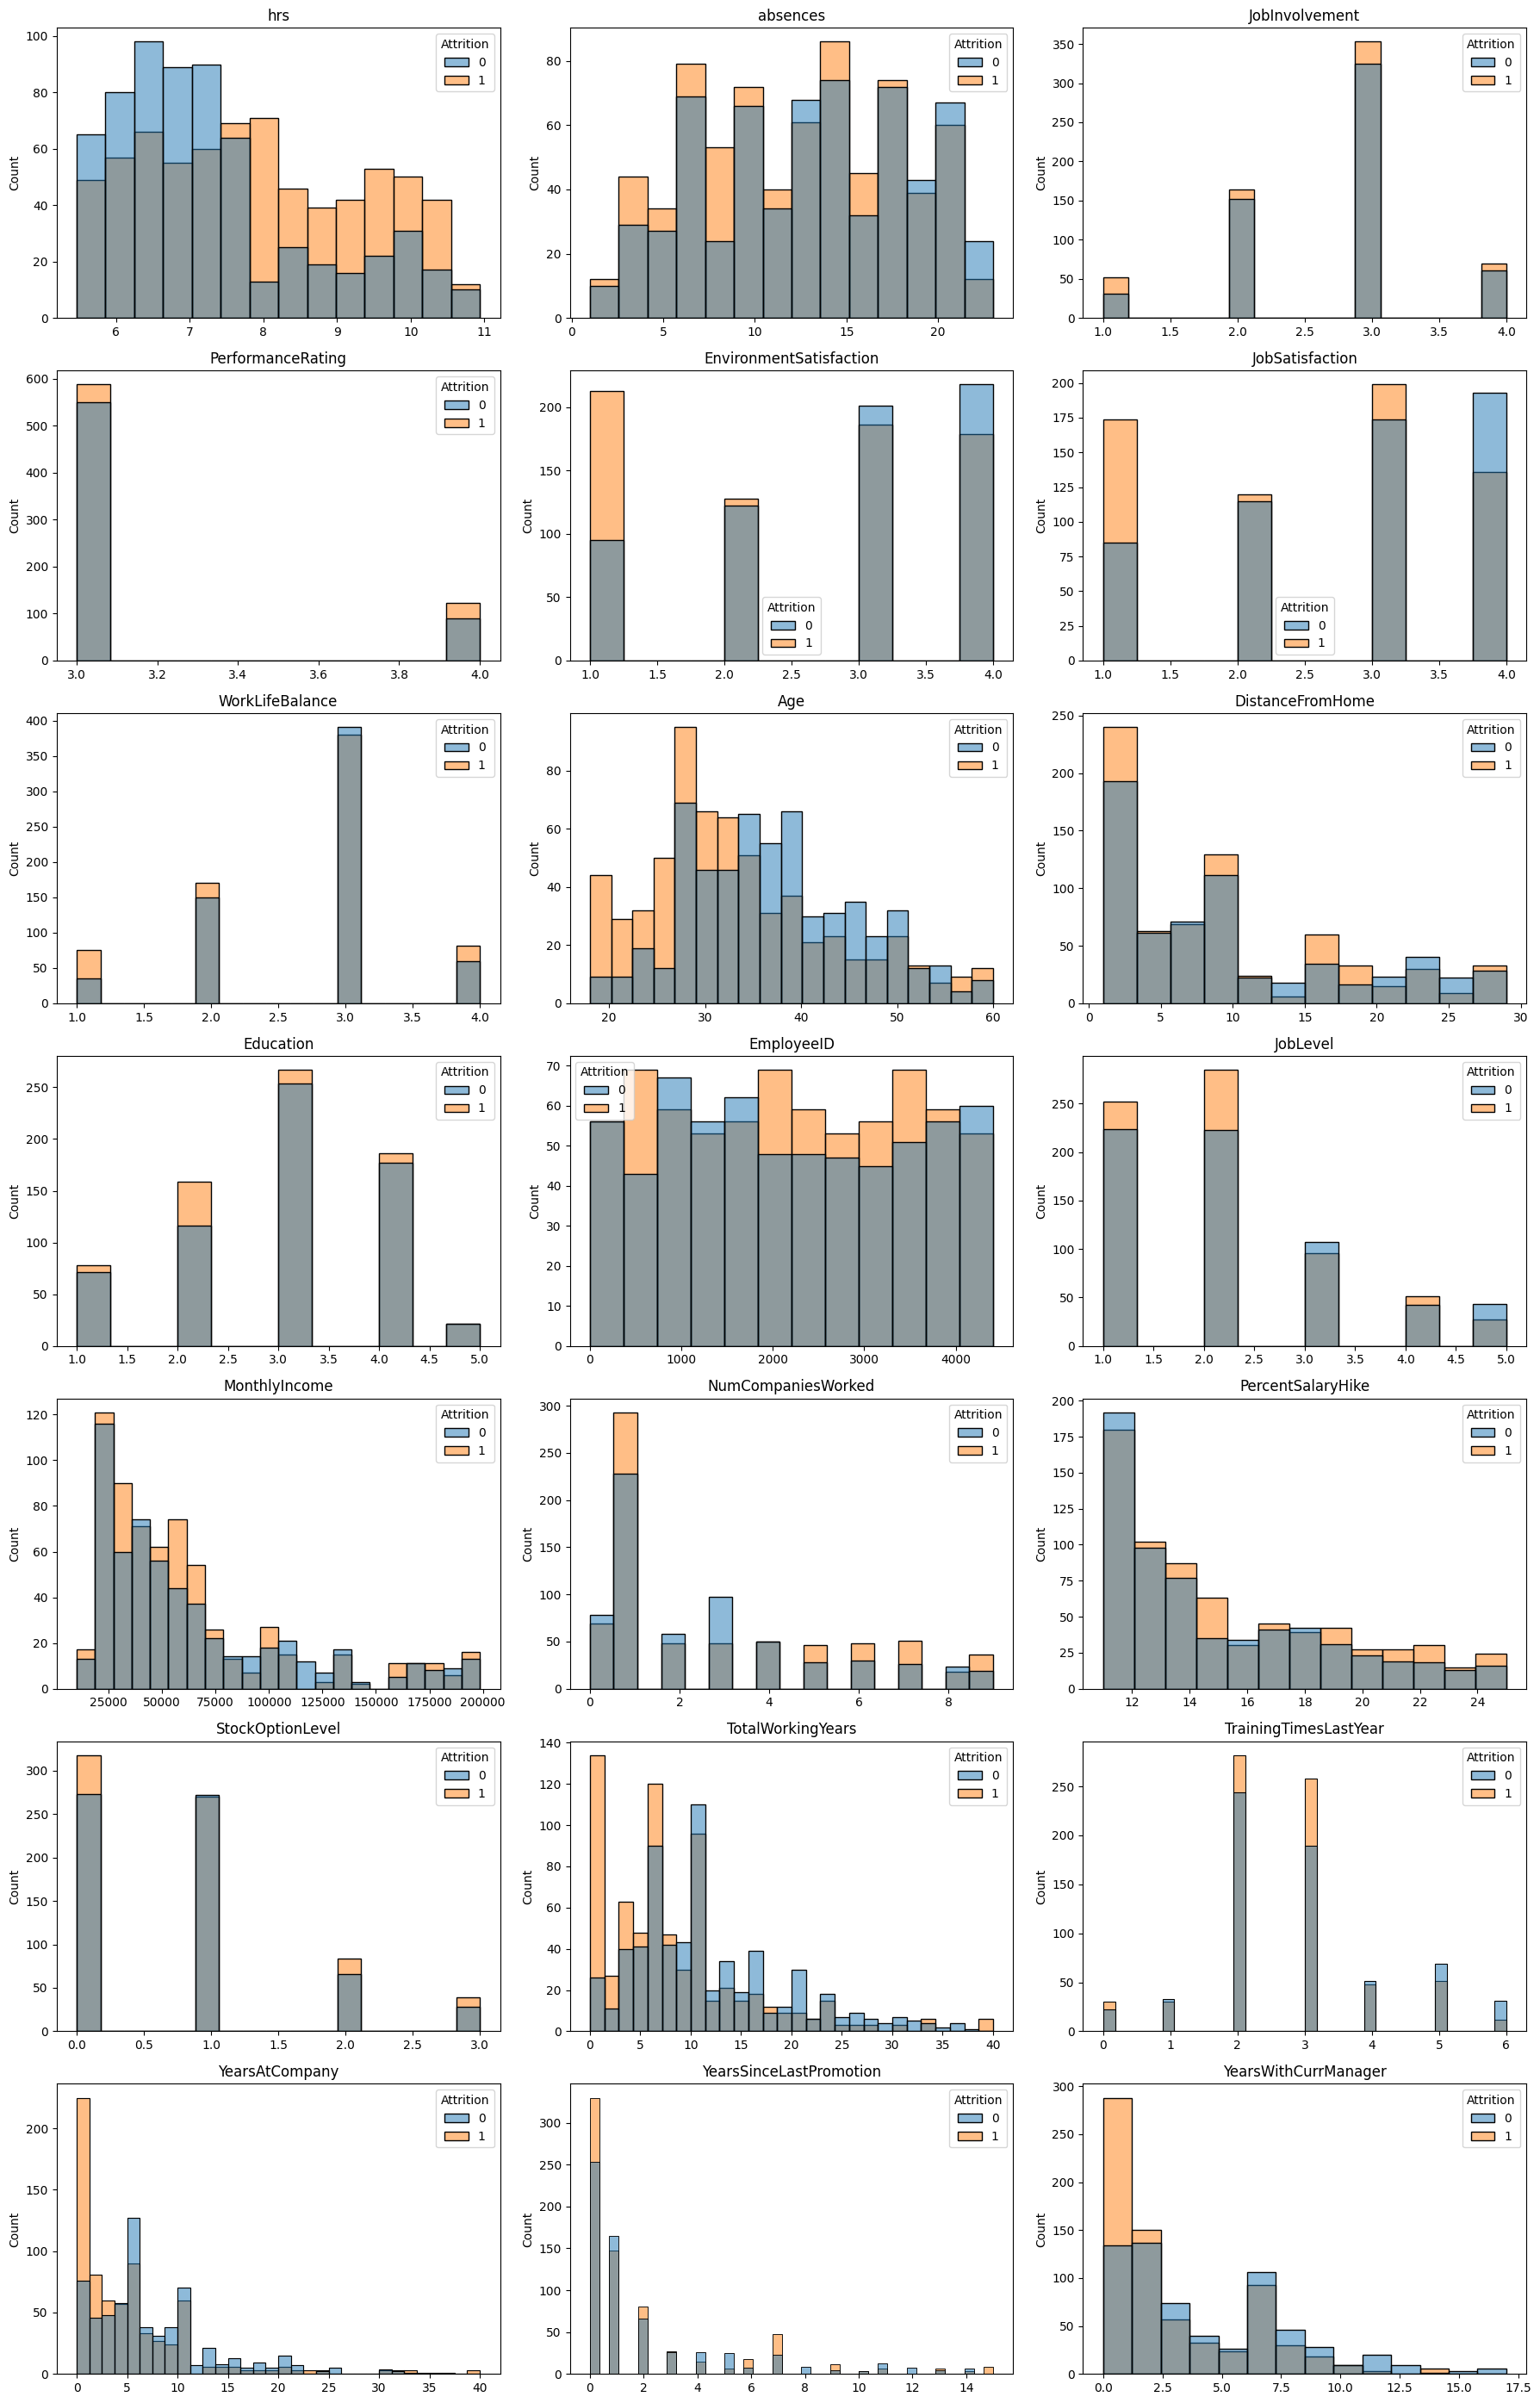

In [53]:
num_cols = df.select_dtypes(include='number').columns
num_cols = [col for col in num_cols if 'Attr' not in col]

n_cols = 3
n_plots = len(num_cols)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        hue='Attrition',
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

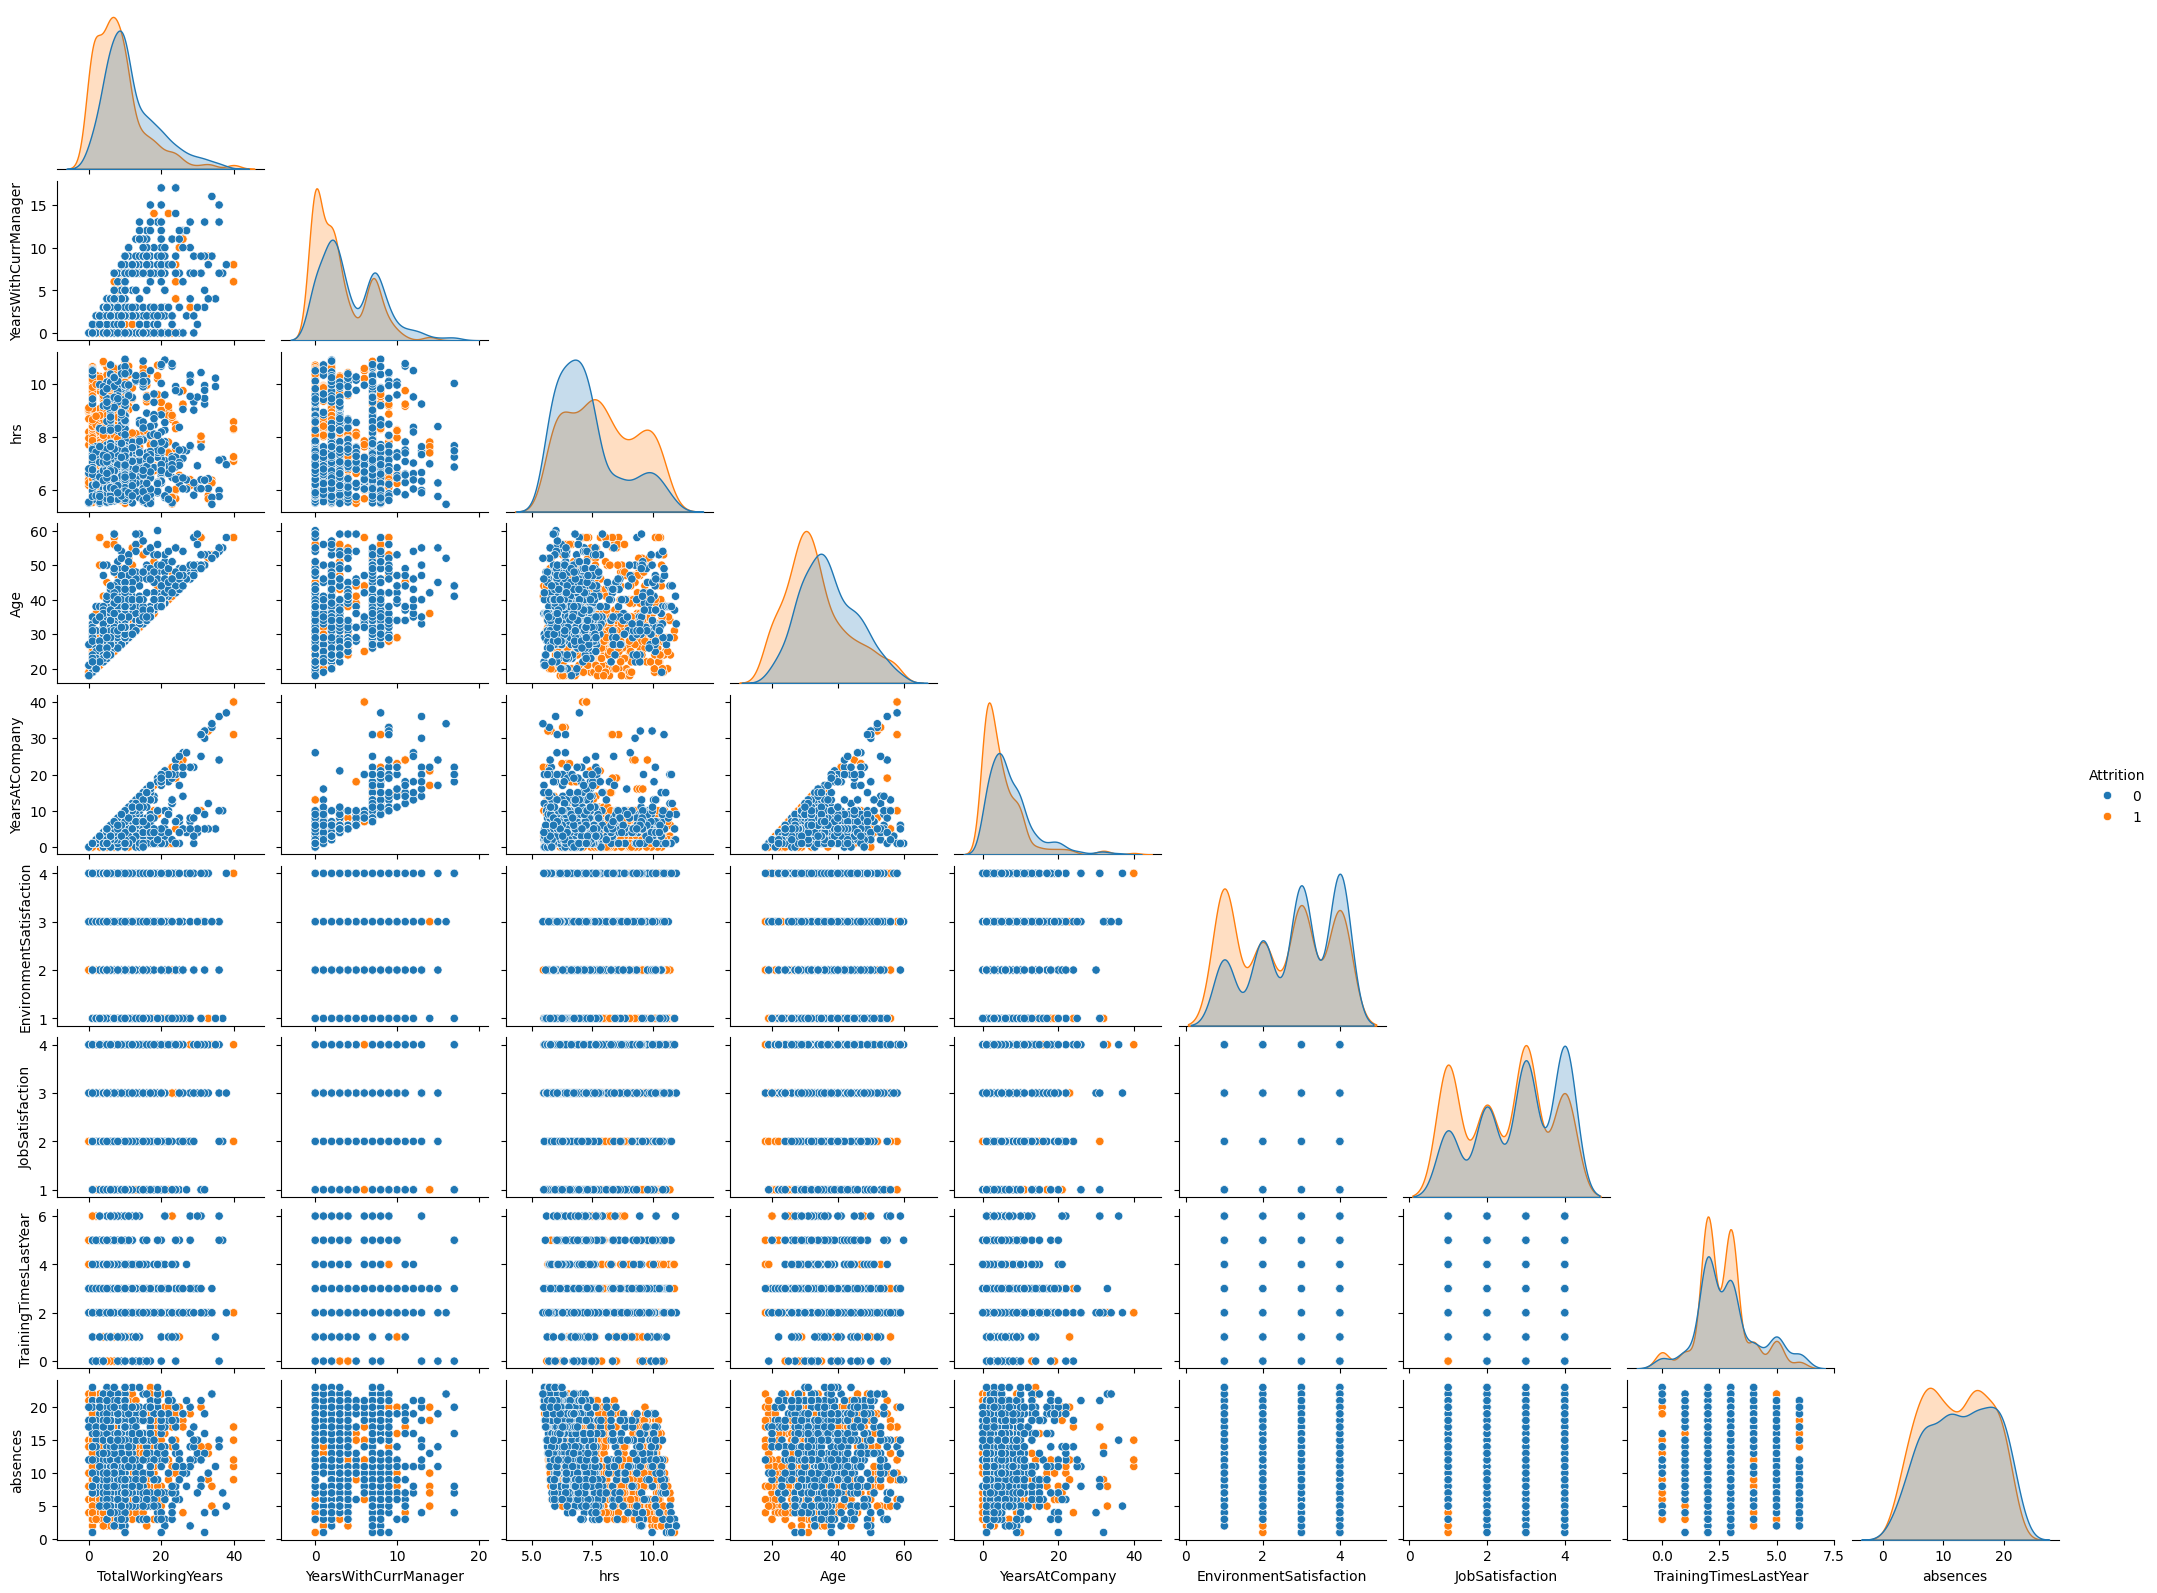

In [54]:
corr = df.corr(numeric_only=True)['Attrition'].abs().sort_values(ascending=False)

top_vars = corr[1:10].index.tolist()

import seaborn as sns
sns.pairplot(df[top_vars + ['Attrition']], hue='Attrition', corner=True, height=1.8, aspect=1.3)

### Baseline

Suponiendo que sería más costoso perder un empleado que destinar recursos extras para retenerlo que no siempre necesariamente implicarian recursos economicos, vamos a procurar optimizar recall para minimizar los falsos negativos, sin perder de vista F1-Score para no sacrificar precision en exceso

Nuestro modelo baseline consistiría en pensar que todos los empleados tienen un riesgo considerable de irse, eso nos dejaría con un recall de 1, una precision de 0.52 y un F1-Score de 0.68

## Pipeline

Para evaluar los modelos se utilizó una combinación de hold-out y cross-validation: 
el dataset se dividió en 80% train y 20% test (hold-out), y dentro del conjunto de 
entrenamiento se aplicó StratifiedKFold con 5 folds para la búsqueda de hiperparámetros 
via GridSearchCV. El stratify garantiza que la proporción de la clase positiva se 
mantenga consistente en cada fold.

In [55]:
results = {'Model' : [], 'Recall' : [],'Precision' : [], 'F1-Score' : [], 'Recall_Train':[], 'Precision_Train':[], 'F1-Score_Train':[] ,'Params':[]}


In [56]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve

from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, precision_score, f1_score
from sklearn.metrics import classification_report




X = df.drop(columns=["Attrition","EmployeeID"])
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,     
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

num_cols = X_train.select_dtypes(include="number").columns
cat_cols = X_train.select_dtypes(exclude="number").columns


preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

### Logistic Regression

In [61]:
from sklearn.linear_model import LogisticRegression


pipe_log = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression()),

])

param_grid_log = { 
        "model__penalty": ["l1", "l2"],
        "model__C": [10],
        "model__solver": ["saga"],
        "model__max_iter": [3000]
}

grid_log = GridSearchCV(
    pipe_log,
    param_grid_log,
    cv=cv,
    scoring="recall",
    n_jobs=-1,
    verbose=1
)

grid_log.fit(X_train, y_train)

print("Parámetros:")
print(grid_log.best_params_)

print('------------------')
print(grid_log.best_score_)


y_pred = grid_log.predict(X_test)


Fitting 5 folds for each of 2 candidates, totalling 10 fits
Parámetros:
{'model__C': 10, 'model__max_iter': 3000, 'model__penalty': 'l1', 'model__solver': 'saga'}
------------------
0.7768203695078404


In [62]:
y_pred = grid_log.predict(X_test)

results['Model'].append('Logistic')
results['Recall'].append(recall_score(y_test, y_pred))
results['Precision'].append(precision_score(y_test, y_pred))
results['F1-Score'].append(f1_score(y_test, y_pred))
results['Params'].append(grid_log.best_params_)

y_pred_train = grid_log.predict(X_train)

results['Recall_Train'].append(recall_score(y_train, y_pred_train))
results['Precision_Train'].append(precision_score(y_train, y_pred_train))
results['F1-Score_Train'].append(f1_score(y_train, y_pred_train))

In [63]:
best_log_pipeline = grid_log.best_estimator_

print("---------------------TRAIN---------------------")
print(classification_report(
    y_train,
    best_log_pipeline.predict(X_train)
))

print("---------------------TEST---------------------")
print(classification_report(
    y_test,
    best_log_pipeline.predict(X_test)
))

---------------------TRAIN---------------------
              precision    recall  f1-score   support

           0       0.76      0.70      0.73       511
           1       0.75      0.80      0.77       569

    accuracy                           0.75      1080
   macro avg       0.75      0.75      0.75      1080
weighted avg       0.75      0.75      0.75      1080

---------------------TEST---------------------
              precision    recall  f1-score   support

           0       0.76      0.71      0.74       128
           1       0.75      0.80      0.78       142

    accuracy                           0.76       270
   macro avg       0.76      0.76      0.76       270
weighted avg       0.76      0.76      0.76       270



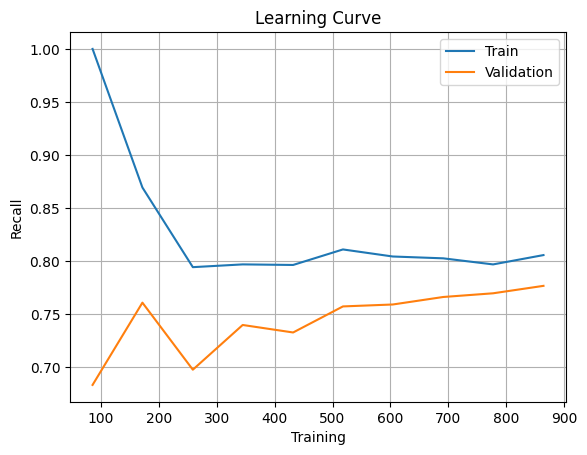

In [64]:
train_sizes, train_scores, test_scores = learning_curve(
    best_log_pipeline,
    X_train,
    y_train,
    cv=cv,                   
    scoring="recall",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, test_mean, label="Validation")

plt.xlabel("Training")
plt.ylabel("Recall")
plt.title("Learning Curve")
plt.legend()
plt.grid()
plt.show()

### SVM

In [891]:
from sklearn.svm import SVC

pipe_svm = Pipeline([
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=42))
])

param_grid_svm = {
    "model__C": [0.1,1,10],
    "model__kernel": ["linear"],
    "model__gamma": ["scale", "auto"],
    "model__class_weight": ["balanced"]
}

grid_svm = GridSearchCV(
    pipe_svm,
    param_grid=param_grid_svm,
    cv=5,
    scoring="recall",
    n_jobs=-1,
    verbose=2
)


grid_svm.fit(X_train, y_train)

print("Parámetros:")
print(grid_svm.best_params_)

print('------------------')
print(grid_svm.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=linear; total time=   0.2s
[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=linear; total time=   0.2s
[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=linear; total time=   0.2s
[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=auto, model__kernel=linear; total time=   0.3s
[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=linear; total time=   0.3s
[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=linear; total time=   0.3s
[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=auto, model__kernel=linear; total time=   0.3s
[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=auto, model__kernel=linear; total time=   0.3s
[CV] END model__C=0.1, model__c

In [892]:
y_pred = grid_svm.predict(X_test)

results['Model'].append('SVM')
results['Recall'].append(recall_score(y_test, y_pred))
results['Precision'].append(precision_score(y_test, y_pred))
results['F1-Score'].append(f1_score(y_test, y_pred))
results['Params'].append(grid_svm.best_params_)

y_pred_train = grid_svm.predict(X_train)

results['Recall_Train'].append(recall_score(y_train, y_pred_train))
results['Precision_Train'].append(precision_score(y_train, y_pred_train))
results['F1-Score_Train'].append(f1_score(y_train, y_pred_train))

In [893]:
best_svm_pipeline = grid_svm.best_estimator_

print("---------------------TRAIN---------------------")
print(classification_report(
    y_train,
    best_svm_pipeline.predict(X_train)
))

print("---------------------TEST---------------------")
print(classification_report(
    y_test,
    best_svm_pipeline.predict(X_test)
))

---------------------TRAIN---------------------
              precision    recall  f1-score   support

           0       0.76      0.74      0.75       511
           1       0.77      0.79      0.78       569

    accuracy                           0.77      1080
   macro avg       0.77      0.77      0.77      1080
weighted avg       0.77      0.77      0.77      1080

---------------------TEST---------------------
              precision    recall  f1-score   support

           0       0.74      0.73      0.74       128
           1       0.76      0.77      0.77       142

    accuracy                           0.75       270
   macro avg       0.75      0.75      0.75       270
weighted avg       0.75      0.75      0.75       270



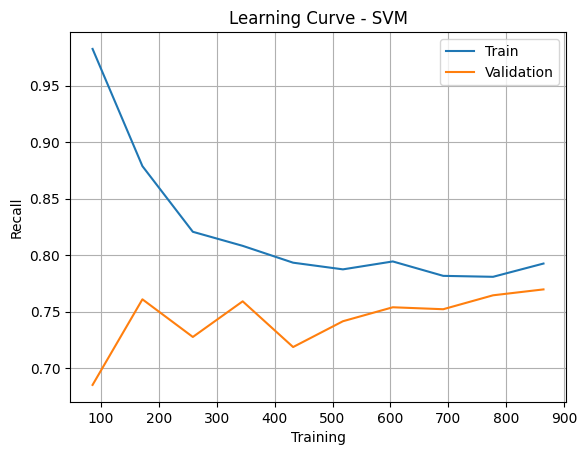

In [941]:
train_sizes, train_scores, test_scores = learning_curve(
    best_svm_pipeline,
    X_train,
    y_train,
    cv=cv,                   
    scoring="recall",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, test_mean, label="Validation")

plt.xlabel("Training")
plt.ylabel("Recall")
plt.title("Learning Curve - SVM")
plt.legend()
plt.grid()
plt.show()

### Random Forest

In [72]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier())
])


param_grid_rf = {'model__max_depth': [5], 'model__max_features': ['sqrt'], 'model__min_samples_leaf': [5], 'model__min_samples_split': [20], 'model__n_estimators': [300]}

grid_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    cv=cv,
    scoring="recall",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Parámetros:")
print(grid_rf.best_params_)

print('------------------')
print(grid_rf.best_score_)

Parámetros:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 20, 'model__n_estimators': 300}
------------------
0.7749107281478032


In [73]:
y_pred = grid_rf.predict(X_test)

results['Model'].append('Random Forest')
results['Recall'].append(recall_score(y_test, y_pred))
results['Precision'].append(precision_score(y_test, y_pred))
results['F1-Score'].append(f1_score(y_test, y_pred))
results['Params'].append(grid_rf.best_params_)

y_pred_train = grid_rf.predict(X_train)

results['Recall_Train'].append(recall_score(y_train, y_pred_train))
results['Precision_Train'].append(precision_score(y_train, y_pred_train))
results['F1-Score_Train'].append(f1_score(y_train, y_pred_train))

In [74]:
best_rf_pipeline = grid_rf.best_estimator_

print("---------------------TRAIN---------------------")
print(classification_report(
    y_train,
    best_rf_pipeline.predict(X_train)
))

print("---------------------TEST---------------------")
print(classification_report(
    y_test,
    best_rf_pipeline.predict(X_test)
))

---------------------TRAIN---------------------
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       511
           1       0.87      0.86      0.86       569

    accuracy                           0.86      1080
   macro avg       0.86      0.86      0.86      1080
weighted avg       0.86      0.86      0.86      1080

---------------------TEST---------------------
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       128
           1       0.83      0.85      0.84       142

    accuracy                           0.83       270
   macro avg       0.83      0.83      0.83       270
weighted avg       0.83      0.83      0.83       270



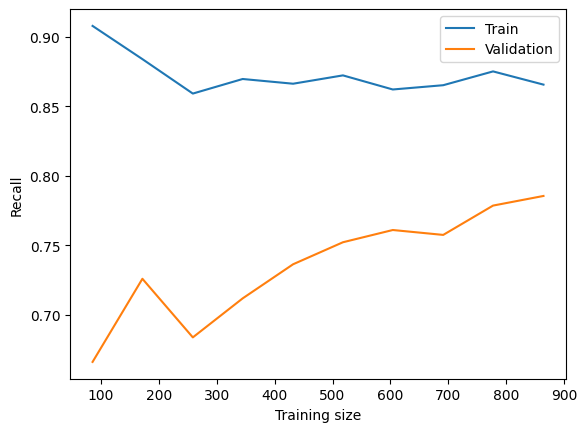

In [75]:
train_sizes, train_scores, val_scores = learning_curve(
    best_rf_pipeline,
    X_train, y_train,
    cv=cv,
    scoring='recall',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation')
plt.xlabel('Training size')
plt.ylabel('Recall')
plt.legend()
plt.show()

### XGBoost

In [128]:
from xgboost import XGBClassifier

pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier())
])

param_grid_xgb = {
    "model__n_estimators": [200],
    "model__max_depth": [3,5],
    "model__learning_rate": [0.01],
    "model__subsample": [0.6, 0.8],
    "model__colsample_bytree": [0.6, 0.7],
    "model__reg_alpha" : [2.0 , 3.0],
    "model__reg_lambda": [3.0]
}

grid_xgb = GridSearchCV(
    pipe_xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X_train, y_train)

print("Parámetros:")
print(grid_xgb.best_params_)

print('------------------')
print(grid_xgb.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END model__colsample_bytree=0.6, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=200, model__reg_alpha=2.0, model__reg_lambda=3.0, model__subsample=0.6; total time=   0.1s
[CV] END model__colsample_bytree=0.6, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=200, model__reg_alpha=2.0, model__reg_lambda=3.0, model__subsample=0.6; total time=   0.1s
[CV] END model__colsample_bytree=0.6, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=200, model__reg_alpha=2.0, model__reg_lambda=3.0, model__subsample=0.6; total time=   0.1s
[CV] END model__colsample_bytree=0.6, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=200, model__reg_alpha=2.0, model__reg_lambda=3.0, model__subsample=0.6; total time=   0.1s
[CV] END model__colsample_bytree=0.6, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=200, model__reg_alpha=2.0, model__reg_lambda=3.0, 

In [129]:
y_pred = grid_xgb.predict(X_test)

results['Model'].append('XGBoost')
results['Recall'].append(recall_score(y_test, y_pred))
results['Precision'].append(precision_score(y_test, y_pred))
results['F1-Score'].append(f1_score(y_test, y_pred))
results['Params'].append(grid_xgb.best_params_)

y_pred_train = grid_xgb.predict(X_train)

results['Recall_Train'].append(recall_score(y_train, y_pred_train))
results['Precision_Train'].append(precision_score(y_train, y_pred_train))
results['F1-Score_Train'].append(f1_score(y_train, y_pred_train))

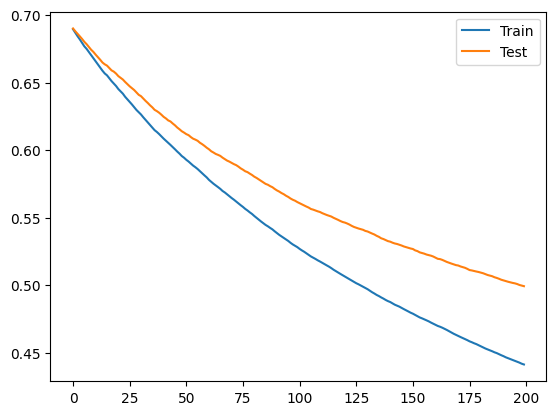

In [130]:
pipeline = grid_xgb.best_estimator_

preprocessor = pipeline.named_steps['preprocessor']

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans  = preprocessor.transform(X_test)

xgb_model = pipeline.named_steps['model']

xgb_model.fit(
    X_train_trans, y_train,
    eval_set=[(X_train_trans, y_train), (X_test_trans, y_test)],
    verbose=False
)

evalresults = xgb_model.evals_result()


plt.plot(evalresults['validation_0']['logloss'], label='Train')
plt.plot(evalresults['validation_1']['logloss'], label='Test')
plt.legend()
plt.show()

In [131]:
best_xgb_pipeline = grid_xgb.best_estimator_

print("---------------------TRAIN---------------------")
print(classification_report(
    y_train,
    best_xgb_pipeline.predict(X_train)
))

print("---------------------TEST---------------------")
print(classification_report(
    y_test,
    best_xgb_pipeline.predict(X_test)
))

---------------------TRAIN---------------------
              precision    recall  f1-score   support

           0       0.89      0.86      0.87       511
           1       0.88      0.90      0.89       569

    accuracy                           0.88      1080
   macro avg       0.88      0.88      0.88      1080
weighted avg       0.88      0.88      0.88      1080

---------------------TEST---------------------
              precision    recall  f1-score   support

           0       0.83      0.84      0.83       128
           1       0.85      0.85      0.85       142

    accuracy                           0.84       270
   macro avg       0.84      0.84      0.84       270
weighted avg       0.84      0.84      0.84       270



## Resultados Modelos

In [132]:
results_df=pd.DataFrame(results)
results_df.drop_duplicates(subset=['Model','Recall','Precision'])

,Model,Recall,Precision,F1-Score,Recall_Train,Precision_Train,F1-Score_Train,Params
0,Logistic,0.802817,0.754967,0.778157,0.797891,0.749175,0.772766,"{'model__C': 10, 'model__max_iter': 2000, 'mod..."
2,Random Forest,0.823944,0.818182,0.821053,0.820738,0.833929,0.827281,"{'model__max_depth': 4, 'model__max_features':..."
3,Random Forest,0.830986,0.842857,0.836879,0.852373,0.866071,0.859167,"{'model__max_depth': 5, 'model__max_features':..."
4,Random Forest,0.852113,0.834483,0.843206,0.859402,0.865487,0.862434,"{'model__max_depth': 5, 'model__max_features':..."
5,XGBoost,0.873239,0.855172,0.864111,0.929701,0.920000,0.924825,"{'model__colsample_bytree': 0.8, 'model__learn..."
7,XGBoost,0.873239,0.861111,0.867133,0.913884,0.904348,0.909091,"{'model__colsample_bytree': 0.8, 'model__learn..."
8,XGBoost,0.859155,0.859155,0.859155,0.908612,0.888316,0.898349,"{'model__colsample_bytree': 0.8, 'model__learn..."
9,XGBoost,0.943662,0.663366,0.779070,0.943761,0.727642,0.821729,"{'model__colsample_bytree': 0.8, 'model__learn..."
10,XGBoost,0.852113,0.858156,0.855124,0.905097,0.887931,0.896432,"{'model__colsample_bytree': 0.7, 'model__learn..."
11,XGBoost,0.845070,0.851064,0.848057,0.903339,0.878632,0.890815,"{'model__colsample_bytree': 0.7, 'model__learn..."


## Analisis de Errores

Se analizaron los Falsos Negativos (FN) de cada modelo — empleados que efectivamente 
se fueron pero el modelo no detectó — con el objetivo de identificar si existe algún 
perfil sistemático que los modelos no logran capturar.

Para esto se comparó la distribución de cada feature entre los FN de XGBoost y Random Forest mediante KDE plots y boxplots.

Principales hallazgos:
- hrs: RF concentra mas errores para aquellos empleados que trabajan entre 6-8 hrs
- absences: RF concentra mas errores en aquellos que tienen pocas inasistencias  y el XGBoost concentra más cuando tienen elevadas.
- JobInvolvement: RF es mejor evitando falsos negativos que el XGBoost cuando hay poco involucramiento pero es peor cuando el involucramiento es alto
- Age: XGBoost es un mejor clasificador cuando las personas son mayores de 40 y el RF con los mas jovenes.
- Education: RF hace pesar mas el estar mas formado como factor para irse
- MonthlyIncome: XGB es mas certero para valores extremos mientras que el RF predice mejor valores centrales
- YearsAtCompany: RF confia mas en los empleados que estan hace mucho tiempo descuidando que son empleados a punto de retirarse mientras que XGBoost ignora que nuevos empleados son mas propensos a irse

XGBoost comete mas errores de falsos positivos cuando la probabilidad apenas supera el 50% a diferencia de RF que estos casos si los diferencia bien pero comete errores estando más seguro

#### XGBoost & Random Forest

In [82]:
y_pred_xgb = grid_xgb.predict(X_test)
y_pred_rf   = grid_rf.predict(X_test)

df_evaluation = pd.DataFrame({
    "EmployeeID":  df.loc[X_test.index, 'EmployeeID'].values,
    "y_pred_xgb":  y_pred_xgb,
    "y_prob_xgb":  grid_xgb.predict_proba(X_test)[:, 1],
    "y_pred_rf":   y_pred_rf,
    "y_prob_rf":   grid_rf.predict_proba(X_test)[:, 1],
})


df_evaluation = pd.merge(df_evaluation, df, on='EmployeeID', how='left')
df_evaluation.rename(columns={'Attrition': 'y_true'}, inplace=True)

In [83]:
### Tipos de Error por Modelo ###

df_evaluation["fn_xgb"] = (
    (df_evaluation["y_true"] == 1) &
    (df_evaluation["y_pred_xgb"] == 0)
)

df_evaluation["fp_xgb"] = (
    (df_evaluation["y_true"] == 0) &
    (df_evaluation["y_pred_xgb"] == 1)
)

df_evaluation["fn_rf"] = (
    (df_evaluation["y_true"] == 1) &
    (df_evaluation["y_pred_rf"] == 0)
)

df_evaluation["fp_rf"] = (
    (df_evaluation["y_true"] == 0) &
    (df_evaluation["y_pred_rf"] == 1)
)

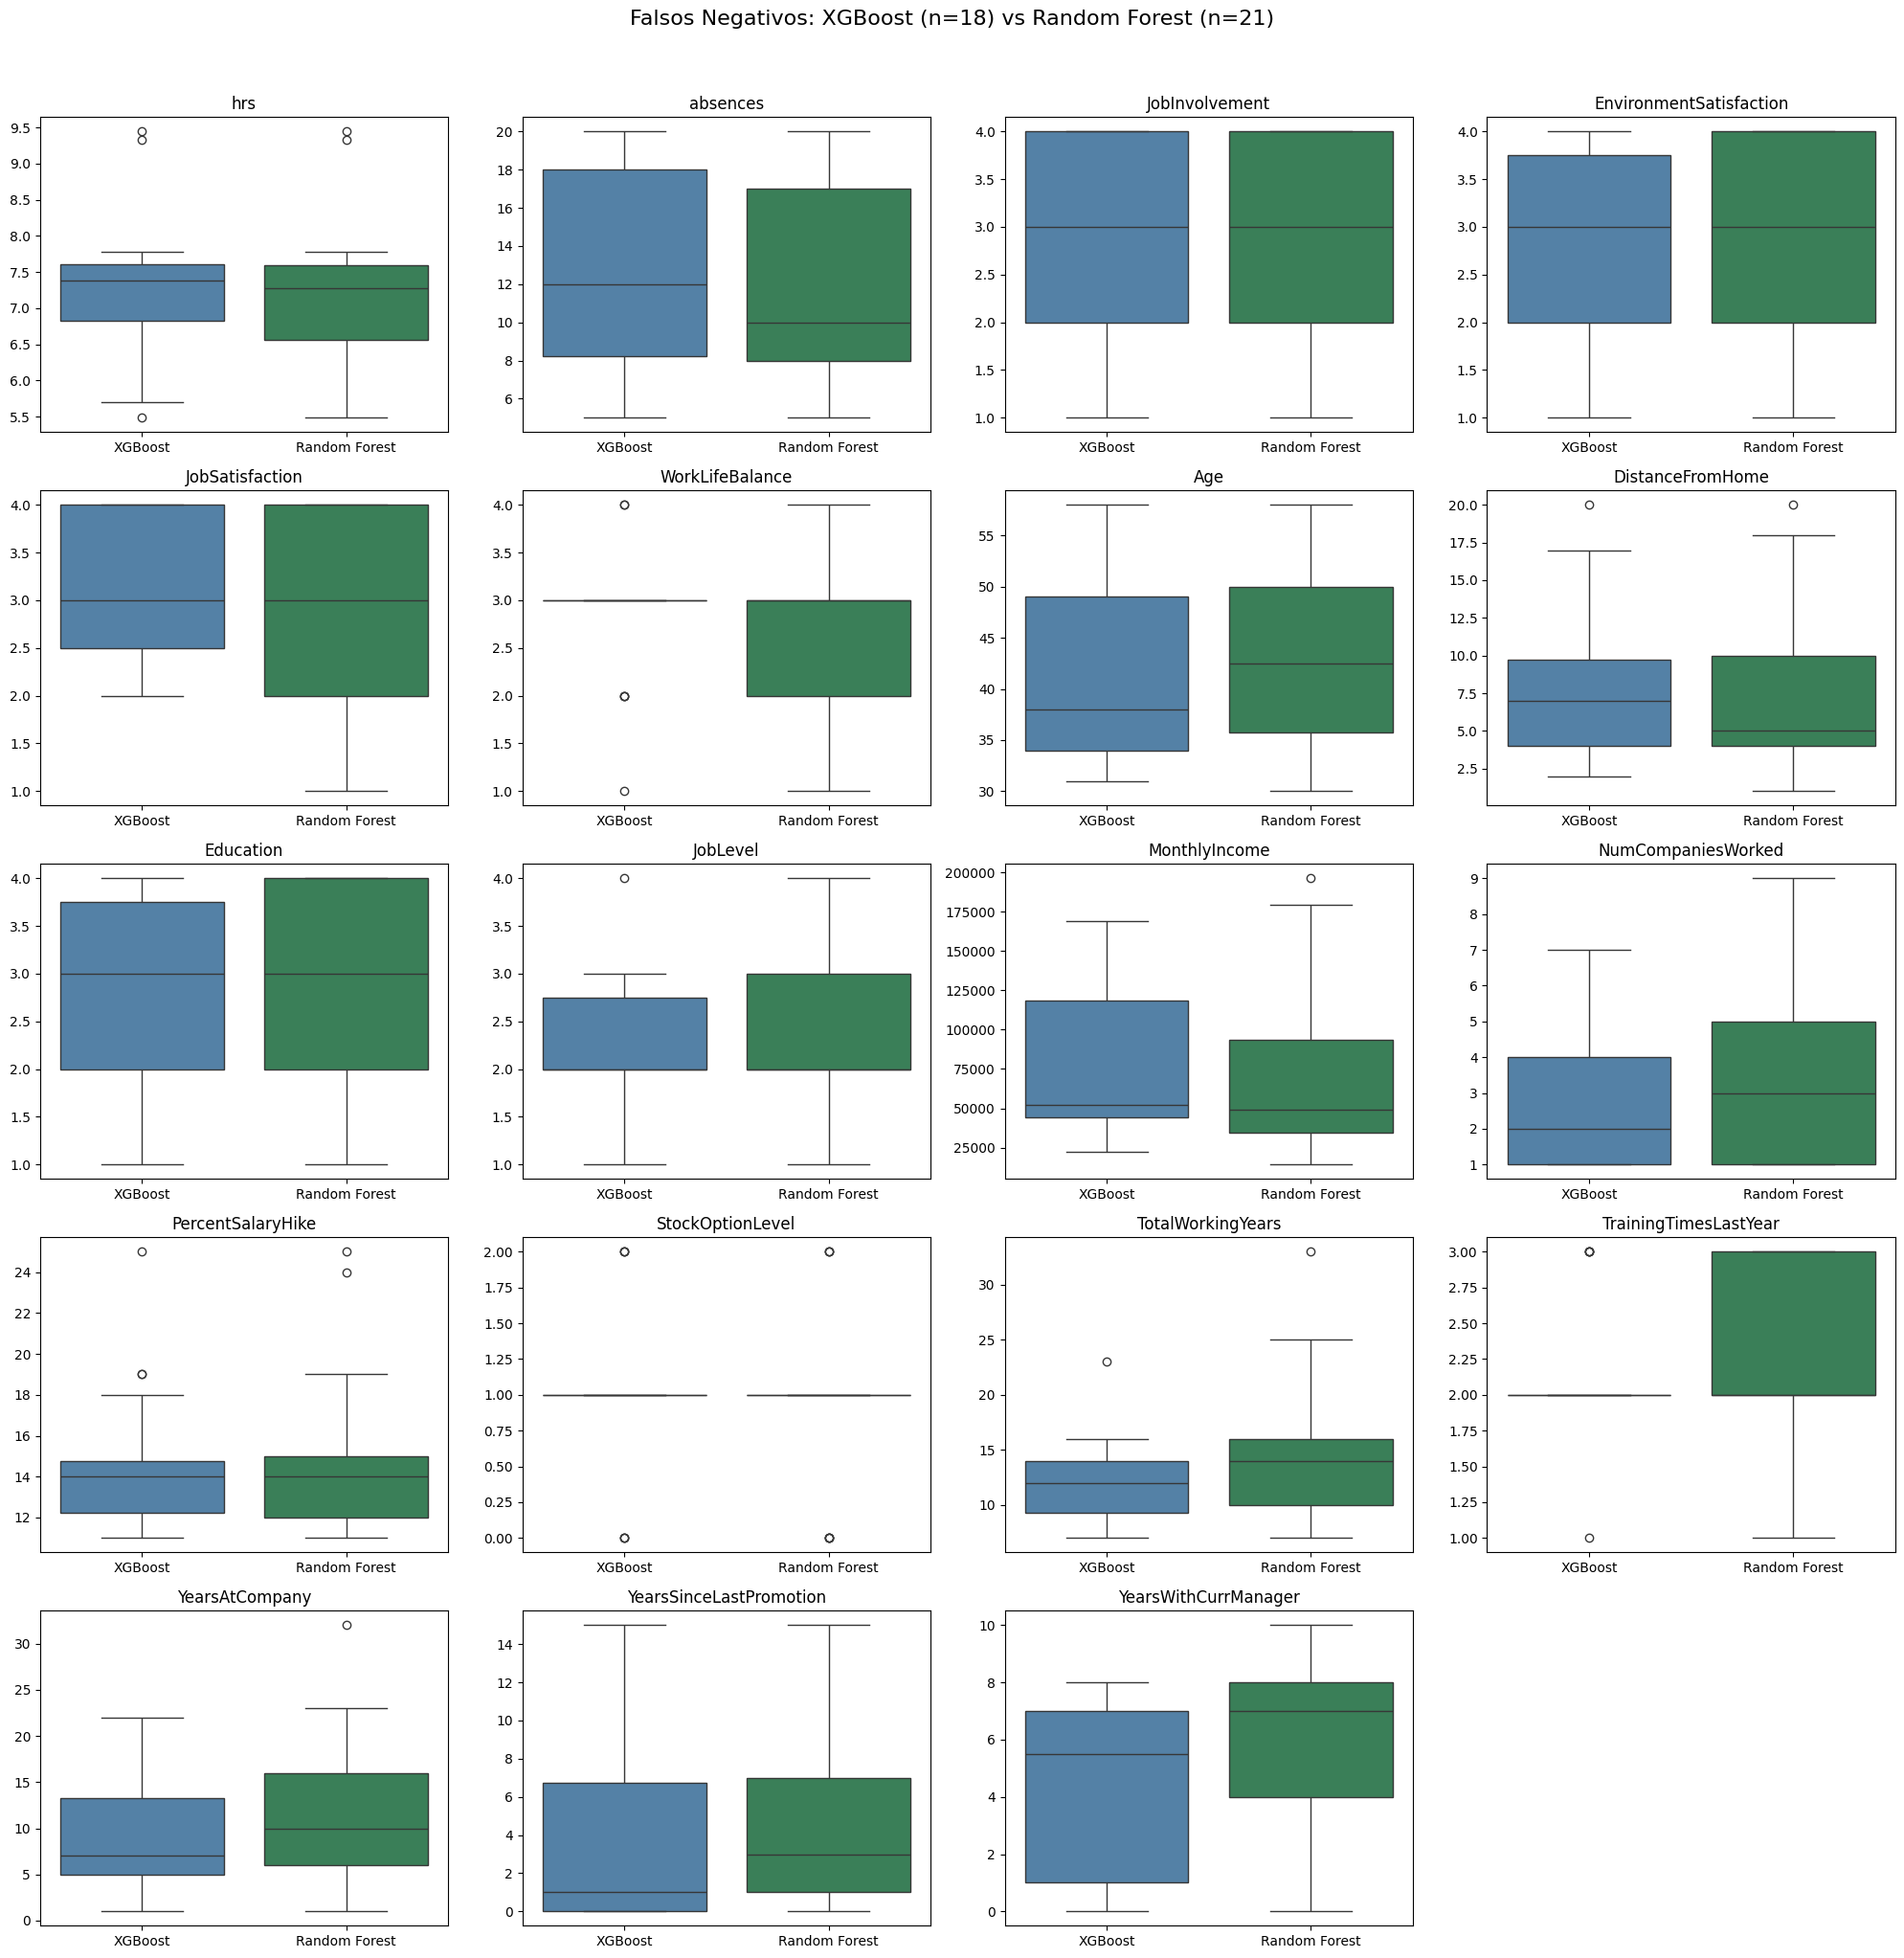

In [84]:
notcols = ['Attrition', 'EmployeeID', 'fn_xgb', 'fn_rf', 'y_true', 'y_pred_xgb', 'y_pred_rf', 'y_prob_xgb', 'y_prob_rf', 'Both_Wrong']

features = [col for col in df_evaluation.select_dtypes(exclude=['object', 'category']) if col not in notcols and 'xgb' not in col and 'rf' not in col]

n_cols = 4
n_rows = math.ceil(len(features) / n_cols)

df_fn_xgb = df_evaluation[df_evaluation['fn_xgb'] == 1].copy()
df_fn_xgb['Model'] = 'XGBoost'

df_fn_rf = df_evaluation[df_evaluation['fn_rf'] == 1].copy()
df_fn_rf['Model'] = 'Random Forest'

df_fn = pd.concat([df_fn_xgb, df_fn_rf]).reset_index(drop=True)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df_fn,
        x='Model',
        y=feature,
        hue='Model',
        palette={'XGBoost': 'steelblue', 'Random Forest': 'seagreen'},
        ax=axes[i]
    )
    axes[i].set_title(feature)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f'Falsos Negativos: XGBoost (n={len(df_fn_xgb)}) vs Random Forest (n={len(df_fn_rf)})', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

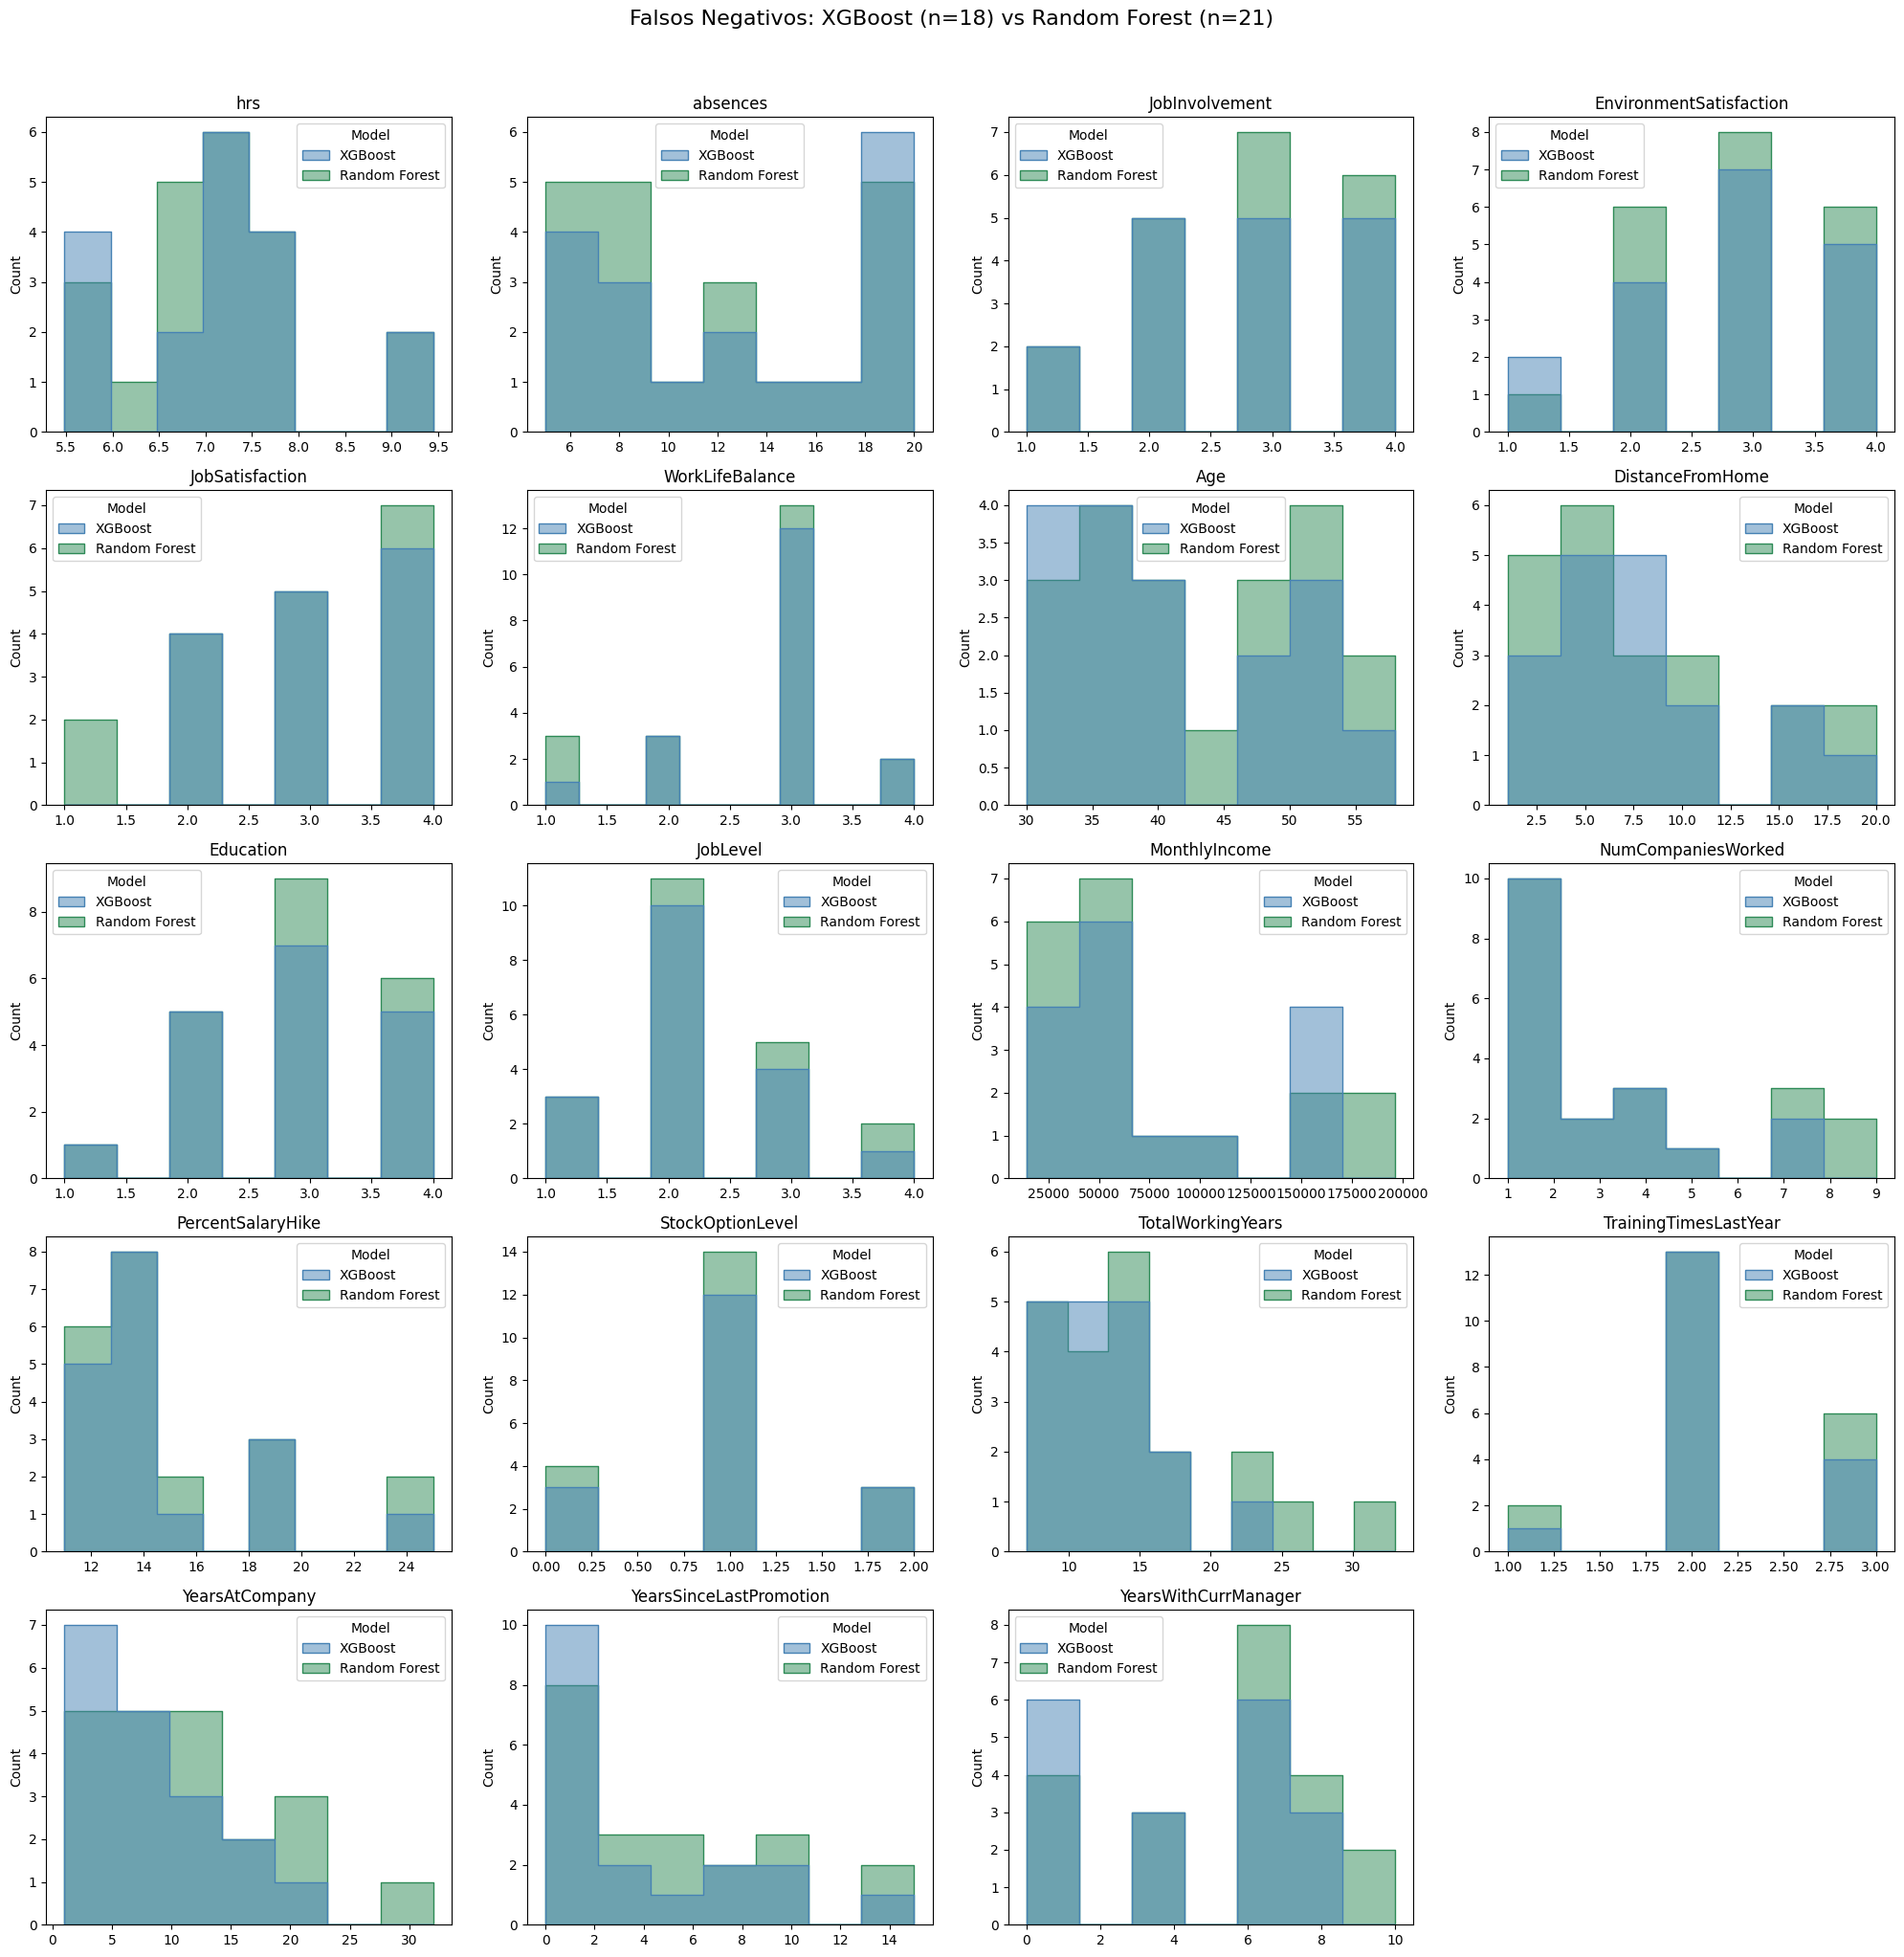

In [85]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(
        data=df_fn,
        x=feature,
        hue='Model',
        palette={'XGBoost': 'steelblue', 'Random Forest': 'seagreen'},
        fill=True,
        alpha=0.5,
        stat='count',
        element='step',
        ax=axes[i]
    )
    axes[i].set_title(feature)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f'Falsos Negativos: XGBoost (n={len(df_fn_xgb)}) vs Random Forest (n={len(df_fn_rf)})', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

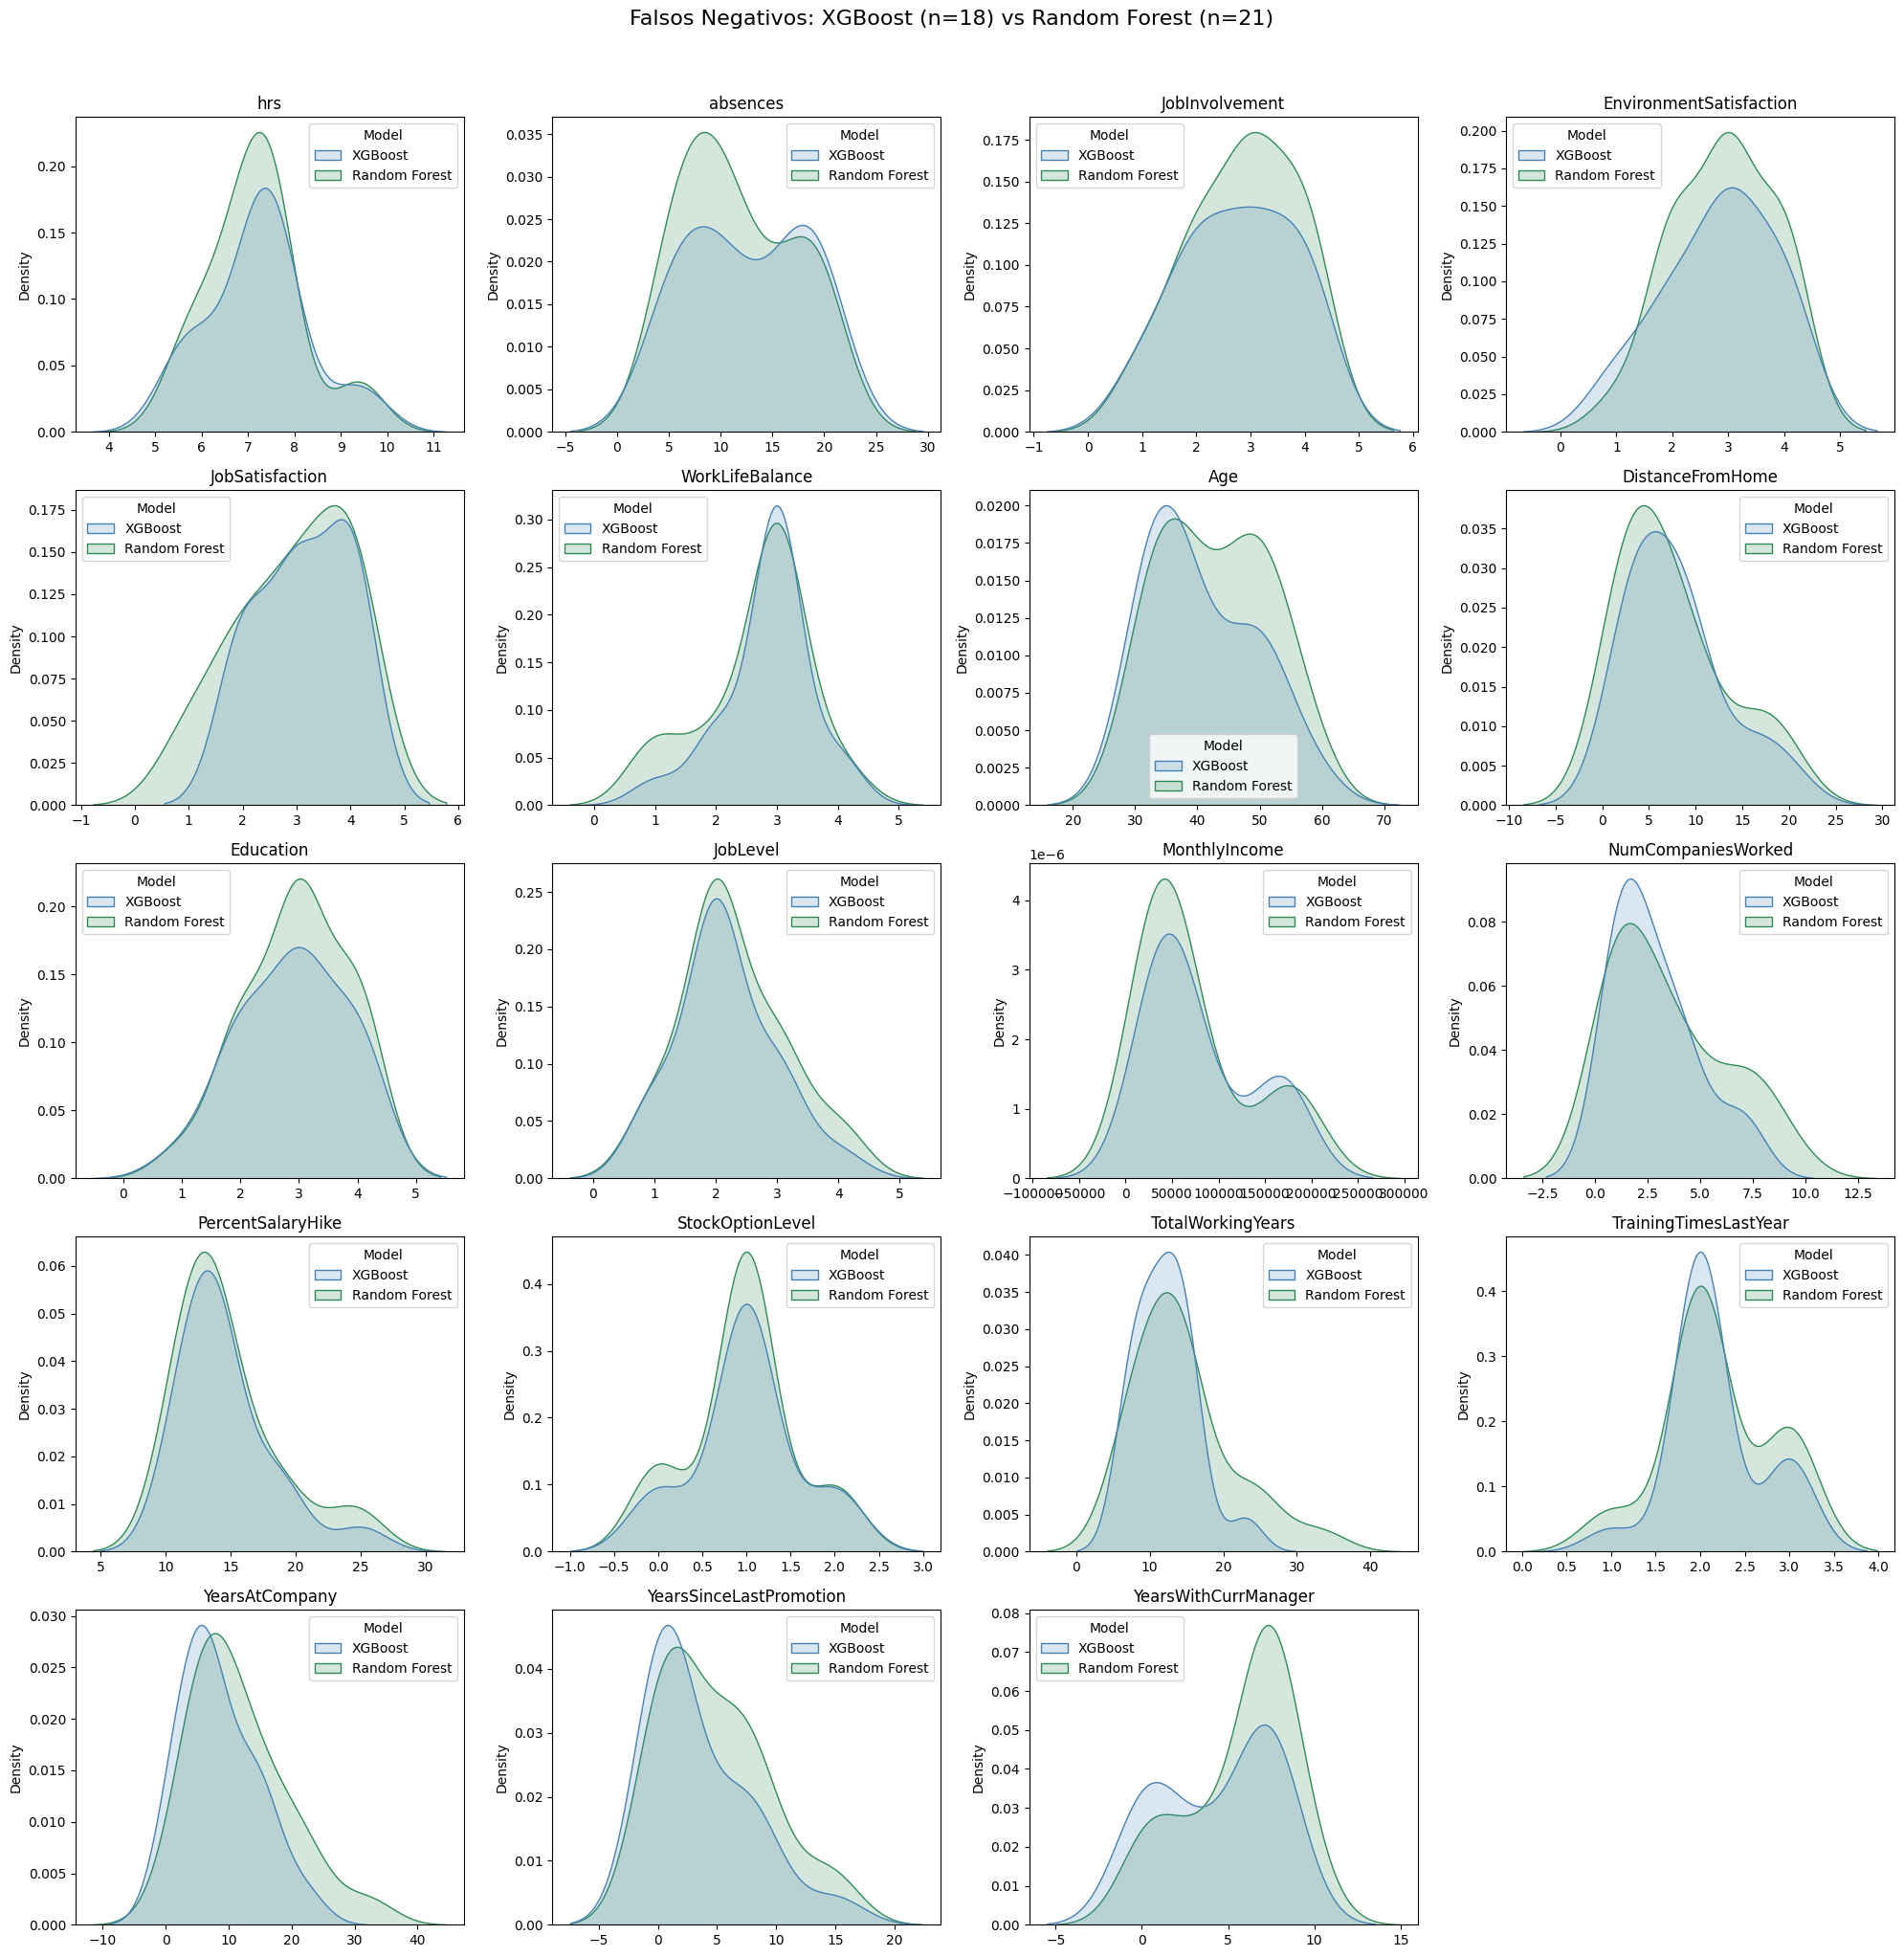

In [86]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.kdeplot(
        data=df_fn,
        x=feature,
        hue='Model',
        palette={'XGBoost': 'steelblue', 'Random Forest': 'seagreen'},
        fill=True,
        alpha=0.2,
        ax=axes[i]
    )
    axes[i].set_title(feature)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f'Falsos Negativos: XGBoost (n={len(df_fn_xgb)}) vs Random Forest (n={len(df_fn_rf)})', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

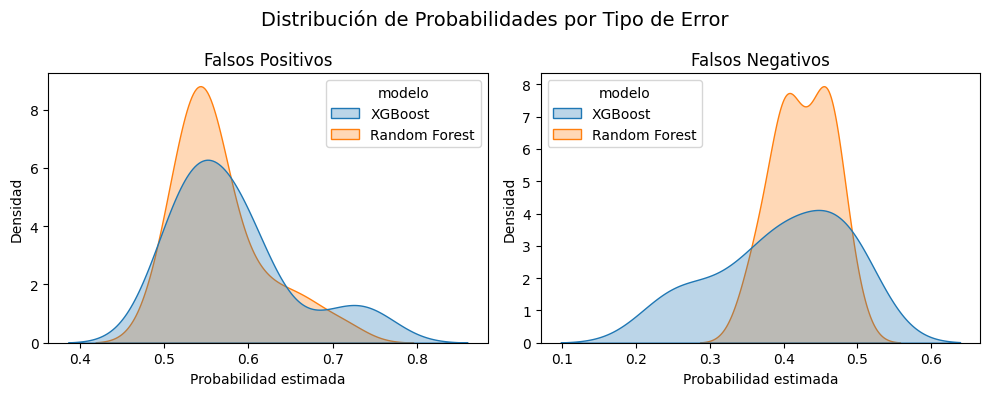

In [104]:
# =========================
# 1️⃣ FALSOS POSITIVOS
# =========================

xgb_fp = df_evaluation.loc[df_evaluation['fp_xgb'] == 1, 'y_prob_xgb']
rf_fp  = df_evaluation.loc[df_evaluation['fp_rf'] == 1, 'y_prob_rf']

df_fp = pd.concat([
    pd.DataFrame({'probabilidad': xgb_fp, 'modelo': 'XGBoost'}),
    pd.DataFrame({'probabilidad': rf_fp,  'modelo': 'Random Forest'})
], ignore_index=True)


# =========================
# 2️⃣ FALSOS NEGATIVOS
# =========================

xgb_fn = df_evaluation.loc[df_evaluation['fn_xgb'] == 1, 'y_prob_xgb']
rf_fn  = df_evaluation.loc[df_evaluation['fn_rf'] == 1, 'y_prob_rf']

df_fn = pd.concat([
    pd.DataFrame({'probabilidad': xgb_fn, 'modelo': 'XGBoost'}),
    pd.DataFrame({'probabilidad': rf_fn,  'modelo': 'Random Forest'})
], ignore_index=True)


# =========================
# 3️⃣ PLOT LADO A LADO
# =========================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Falsos Positivos
sns.kdeplot(
    data=df_fp,
    x='probabilidad',
    hue='modelo',
    fill=True,
    common_norm=False,
    alpha=0.3,
    ax=axes[0]
)

axes[0].set_title('Falsos Positivos')
axes[0].set_xlabel('Probabilidad estimada')
axes[0].set_ylabel('Densidad')


# --- Falsos Negativos
sns.kdeplot(
    data=df_fn,
    x='probabilidad',
    hue='modelo',
    fill=True,
    common_norm=False,
    alpha=0.3,
    ax=axes[1]
)

axes[1].set_title('Falsos Negativos')
axes[1].set_xlabel('Probabilidad estimada')
axes[1].set_ylabel('Densidad')

plt.suptitle('Distribución de Probabilidades por Tipo de Error', fontsize=14)
plt.tight_layout()
plt.show()

In [105]:
def best_threshold_f1(y_true, y_prob):
    thresholds = np.linspace(0, 1, 1000)
    best_t = 0
    best_f1 = 0
    
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        score = f1_score(y_true, y_pred)
        
        if score > best_f1:
            best_f1 = score
            best_t = t
            
    return best_t, best_f1

t_xgb, f1_xgb = best_threshold_f1(df_evaluation['y_true'], df_evaluation['y_prob_xgb'])
t_rf, f1_rf   = best_threshold_f1(df_evaluation['y_true'], df_evaluation['y_prob_rf'])

print("XGB ->", t_xgb, f1_xgb)
print("RF  ->", t_rf, f1_rf)

XGB -> 0.4844844844844845 0.8737201365187713
RF  -> 0.4984984984984985 0.8432055749128919


In [95]:
df_evaluation[df_evaluation['fn_xgb']==1]['y_prob_xgb'].max()

np.float32(0.49413216)

In [ ]:
df_evaluation["error_xgb"] = df_evaluation["y_pred_xgb"] != df_evaluation["y_true"]
df_evaluation["error_rf"]  = df_evaluation["y_pred_rf"]  != df_evaluation["y_true"]

df_evaluation["Group"] = "Correct"

df_evaluation.loc[
    df_evaluation["error_xgb"] & df_evaluation["error_rf"],
    "Group"
] = "Incorrect"

df_evaluation.loc[
    df_evaluation["error_xgb"] & ~df_evaluation["error_rf"],
    "Group"
] = "Rf_correct"

df_evaluation.loc[
    ~df_evaluation["error_xgb"] & df_evaluation["error_rf"],
    "Group"
] = "Xgb_correct"

df_evaluation["Group"].value_counts(normalize=True)

Group
Correct        0.803704
Incorrect      0.114815
Xgb_correct    0.051852
Rf_correct     0.029630
Name: proportion, dtype: float64

In [ ]:
df_evaluation["high_confidence_xgb"] = (
    (df_evaluation["error_xgb"]) &
    (df_evaluation["y_prob_xgb"] > 0.9)
)
df_evaluation["high_confidence_rf"] = (
    (df_evaluation["error_rf"]) &
    (df_evaluation["y_prob_rf"] > 0.9)
)

print(df_evaluation['high_confidence_rf'].value_counts(normalize=True))


print(df_evaluation['high_confidence_rf'].value_counts(normalize=True))

high_confidence_rf
False    1.0
Name: proportion, dtype: float64
high_confidence_rf
False    1.0
Name: proportion, dtype: float64


In [ ]:
df_evaluation["Both_Wrong"] = (
    df_evaluation["Group"] == "Incorrect"
)

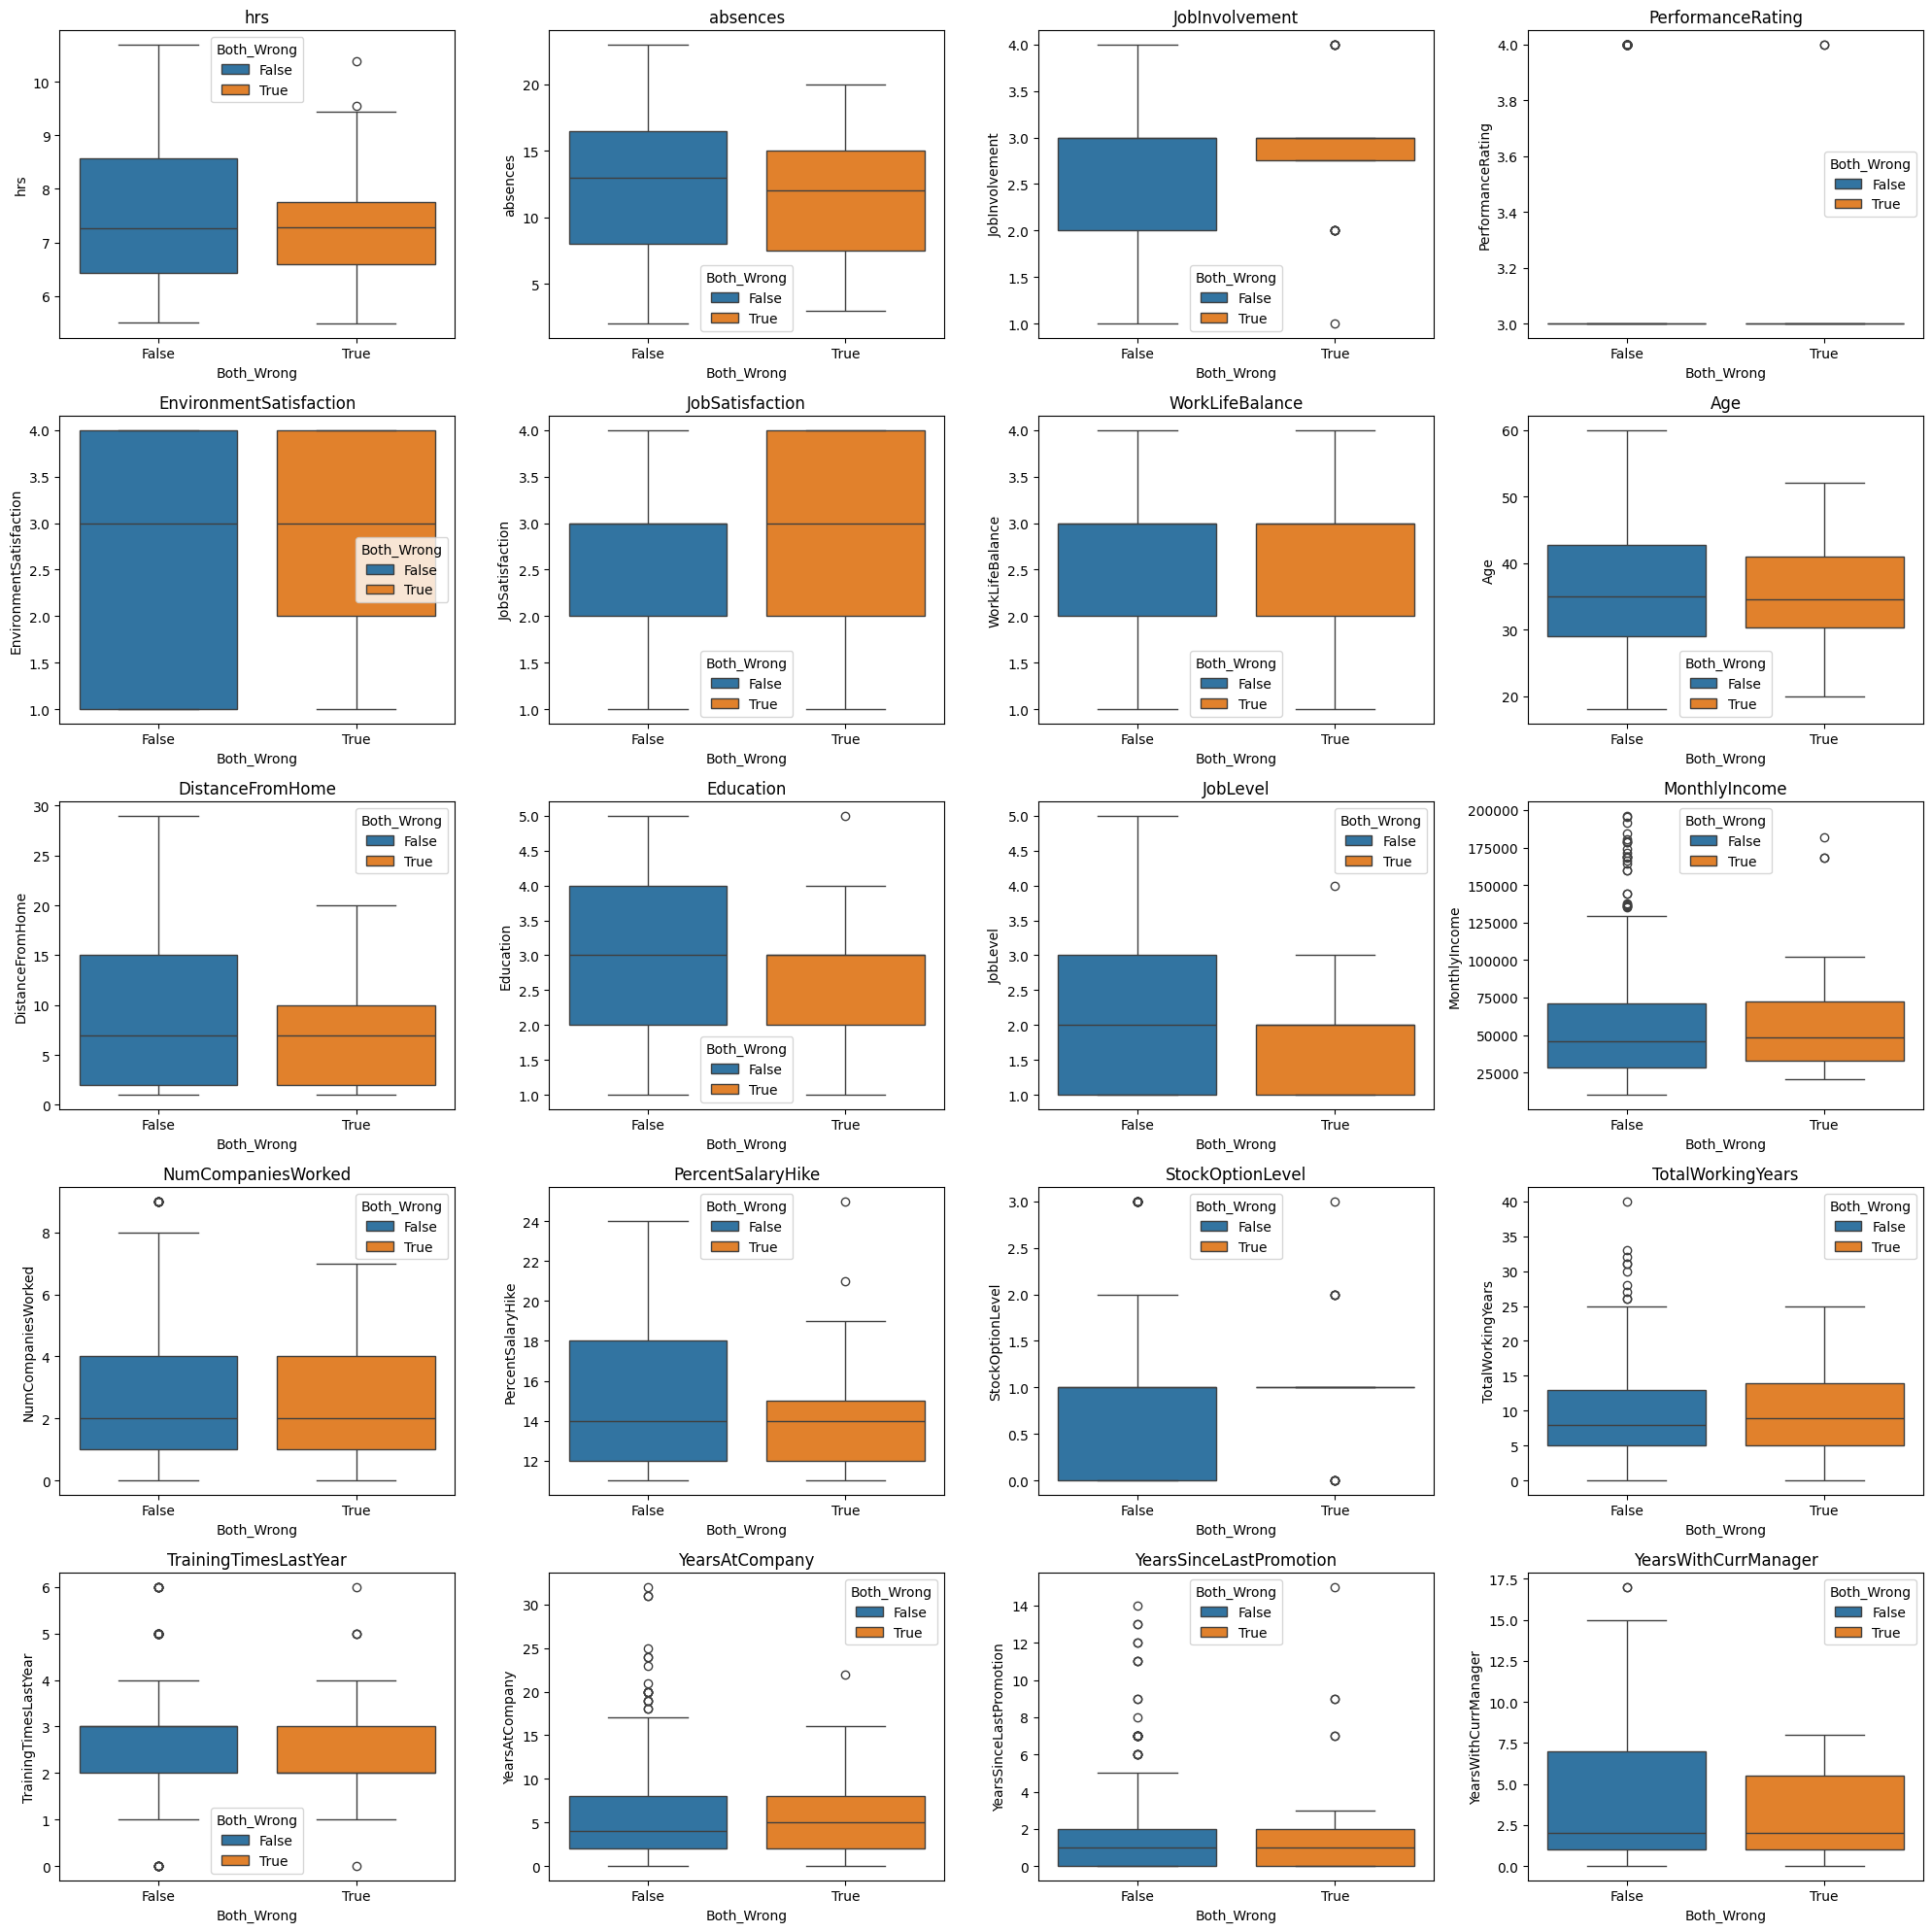

In [ ]:
notcols = ['Attrition','EmployeeID']

features = [col for col in df.select_dtypes(exclude=['object', 'category']) if col not in notcols]

n_cols = 4
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df_evaluation,
        x="Both_Wrong",
        y=feature,
        hue= 'Both_Wrong',
        ax=axes[i]
    )
    axes[i].set_title(feature)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### PKL

In [ ]:
import pickle

with open('XGB.pkl', 'wb') as f:
    pickle.dump(best_xgb_pipeline, f)